In [1]:
import numpy as np
from collections import deque

class BiomechanicalFilter:
    def __init__(self, mode='healthy'):
        """
        初始化滤波器
        :param mode: 'healthy', 'parkinson', 'stroke', 'ataxia'
        :param dt: 仿真步长 (秒)
        """
        self.mode = mode
        self.t = 0
        
        # --- 帕金森参数 (基于 Rocon et al. 2004) ---
        self.tremor_amp = 0.4     # 震颤幅度 (像素或单位距离)
        self.tremor_freq = 1/8    # 频率 Hz (4-6Hz 是典型值)
        
        # --- 中风参数 (基于 Rohrer et al. 2002) ---
        self.drag_factor = 0.6    # 肌无力: 只能发挥 60% 的速度
        self.submove_timer = 0    # 子运动计时器
        self.is_stuck = False     # 是否处于"停顿"状态
        
        # --- 共济失调参数 (基于 Manto et al. 1994) ---
        self.dysmetria_gain = 1.5 # 过冲系数 (意向性震颤)
        self.momentum = np.zeros(2) # 惯性/动量
        self.friction = 0.1       # 模拟刹不住车的摩擦系数
        
        # --- 通用: 延迟缓冲区 ---
        self.delay_buffer = deque(maxlen=10) # 模拟反应延迟

    def reset(self):
        self.t = 0
        self.momentum = np.zeros(2)
        self.delay_buffer.clear()
        self.is_stuck = False

    def apply(self, ideal_action, current_pos, target_pos=None):
        """
        核心函数
        :param ideal_action: (dx, dy) 原始动作，假设范围 [-1, 1] 或速度向量
        :param current_pos: 当前手的位置 (x, y)
        :param target_pos: 目标位置 (用于共济失调计算距离)，可选
        :return: (dx, dy) 实际执行的动作
        """
        self.t += 1
        
        # 1. 基础处理：将其转换为 numpy 数组
        action = np.array(ideal_action, dtype=float)

        # 2. 根据模式分发处理
        if self.mode == 'healthy':
            final_action = self._apply_healthy(action)
            
        elif self.mode == 'parkinson':
            final_action = self._apply_parkinson(action)
            
        elif self.mode == 'stroke':
            final_action = self._apply_stroke(action)
            
        elif self.mode == 'ataxia':
            final_action = self._apply_ataxia(action, current_pos, target_pos)
            
        else:
            final_action = action

        # 3. 全局物理约束 (Sim2Real 保护)
        # 防止瞬间速度过大导致物理引擎穿模
        final_action = np.clip(final_action, -10, 10) # 假设最大速度限制
        
        return final_action

    # ---------------- 具体病理实现 ----------------

    def _apply_healthy(self, action):
        # 正常人也有微小的 Minimum Jerk 平滑，这里简化为不做改动
        # 或者加极微小的高斯噪声模拟传感器误差
        return action

    def _apply_parkinson(self, action):
        """
        模型依据: Rocon et al. (2004)
        叠加正弦震颤 + 随机高斯噪声
        """
        # 计算震颤向量
        tremor_x = self.tremor_amp * np.sin(2 * np.pi * self.tremor_freq * self.t)
        tremor_y = self.tremor_amp * np.cos(2 * np.pi * self.tremor_freq * self.t)
        
        # 随机相位漂移 (让震颤看起来不那么机械)
        noise = np.random.normal(0, 0.2, 2)
        
        return action + np.array([tremor_x, tremor_y]) + noise

    def _apply_stroke(self, action):
        """
        模型依据: Rohrer et al. (2002) - Submovements
        表现为: 迟缓 (Lag) + 间歇性停顿 (Stuttering) + 速度削弱
        """
        # 1. 模拟神经延迟 (Lag)
        self.delay_buffer.append(action)
        if len(self.delay_buffer) < 4: # 假设延迟 3 帧
            return np.zeros(2)
        delayed_action = self.delay_buffer.popleft()
        
        # 2. 模拟子运动 (间歇性停顿)
        # 每隔一段时间随机"卡住"一下
        if self.submove_timer <= 0:
            if np.random.rand() < 0.1: # 10% 概率进入停顿
                self.is_stuck = True
                self.submove_timer = np.random.randint(2, 5) # 停顿 5-15 帧
            else:
                self.is_stuck = False
                self.submove_timer = np.random.randint(5, 10) # 正常运动 20-60 帧
        
        self.submove_timer -= 1
        
        if self.is_stuck:
            return delayed_action * 0.1 # 几乎不动
        else:
            # 3. 肌无力 (Weakness)
            return delayed_action * self.drag_factor

    def _apply_ataxia(self, action, current_pos, target_pos):
        """
        模型依据: Manto et al. (1994) - Dysmetria
        表现为: 惯性过大 (刹不住车) + 距离相关的抖动
        """
        # 1. 意向性震颤 (距离目标越近，抖动越大)
        dist_noise = 0
        if target_pos is not None:
            dist = np.linalg.norm(current_pos - target_pos)
            # 距离越近(dist小)，噪声因子反而需要处理，
            # 这里简化为：速度增益误差
        
        # 2. 动量模型 (High Momentum / Low Friction)
        # 新的速度不是直接等于 Action，而是很大程度上受上一步速度影响
        # V_new = V_old * (1 - friction) + Action * Gain
        
        self.momentum = self.momentum * (1 - self.friction) + action * self.dysmetria_gain
        
        return self.momentum
    def _apply_attention(self):
        pass


In [2]:
import numpy as np
from collections import deque

class ParametricPatient:
    def __init__(self):
        """
        :param dt: 仿真步长 (秒)，例如 1/20fps = 0.05s
        """
        self.t = 0
        
        # 动作延迟缓冲区 (用于模拟 Lag)
        # 假设最大延迟 1.0秒，分配足够的 buffer 空间
        max_buffer_size = 5
        self.action_buffer = deque(maxlen=max_buffer_size)

        
        # 当前参数字典
        self.params = {}
        self.reset_randomly()


    def reset_randomly(self):
        """
        [核心功能] 每一局开始前调用。
        从指定的分布中采样，生成一个独一无二的'虚拟病人'。
        """
        self.t = 0
        self.action_buffer.clear()
        
        # --- 1. 最大速度能力 (v_max) ---
        # U(0.5, 8.0) cm/s
        # 决定了病人能跑多快
        self.params["v_max"] = np.random.uniform(0.5, 2)
        
        # --- 2. 反应延迟 (Lag) ---
        # U(0, 0.8) 秒
        # 决定了动作滞后多少帧
        self.params["lag_time"] = np.random.randint(0, 3)
        self.lag_steps = int(self.params["lag_time"])
        
        # --- 3. 震颤幅度 (Tremor Amp) ---
        
        # 高斯噪声，二维的
        self.params["tremor_mean"] = np.random.uniform(-0.2, 0.2,size=2)
        self.params["tremor_std"] = np.random.uniform(0, 0.03, size=(2,))

        
        
        # --- 5. 追踪意愿 (Gain) ---
        # U(0.5, 1.5)
        # 作为 P-Controller 的比例系数，决定了接近目标的“急切程度”
        self.params["gain"] = np.random.uniform(0.2, 0.5)
        
        # 初始化 Buffer (填满0，防止刚开始报错)
        for _ in range(self.action_buffer.maxlen):
            self.action_buffer.append(np.zeros(2))
            
        return self.params

    def get_velocity(self, hand_pos, robot_pos):
        """
        计算当前帧手部的速度向量
        """
        self.t += 1
        
        # --- A. 计算意图 (Intent) ---
        # 简单的 P-Control: 速度与距离成正比
        error_vec = robot_pos - hand_pos
        dist = np.linalg.norm(error_vec)
        
        if dist < 1e-4:
            intent_vel = np.zeros(2)
        else:
            direction = error_vec / dist
            
            # 基础速度 = 距离 * Gain
            desired_speed = dist * self.params["gain"]

            
            
            # [关键] 物理能力限制 (v_max)
            # 无论多想追，速度不能超过生理极限
            real_speed = np.clip(desired_speed, 0.5,self.params["v_max"])
            
            intent_vel = direction * real_speed

        # --- B. 叠加震颤 (Tremor) ---

        tremor_vec = np.random.normal(self.params["tremor_mean"], self.params["tremor_std"])
            
            # 震颤叠加在意图上
        current_raw_vel = intent_vel + tremor_vec


        # --- C. 模拟延迟 (Lag) ---
        # 将当前算出的"大脑指令"存入缓冲区
        self.action_buffer.append(current_raw_vel)
        
        # 取出滞后的指令作为"肌肉执行"
        # buffer[-1] 是最新的，buffer[-lag_steps] 是过去的
        idx = max(1, len(self.action_buffer) - 1 - self.lag_steps)
        final_vel = self.action_buffer[idx]
        
        return final_vel

In [3]:
import gymnasium as gym
from gymnasium.spaces import Box,Dict
import numpy as np
import pygame
import pygame.gfxdraw
import math
import random
import os
import json
import time
from collections import deque



# --- Main Environment Class ---
class RehabilitationEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 60}

    def __init__(self, 
                 training_mode='robot', # 'robot' or 'hand'
                 robot_model=None,      # 训练 Hand 时需要的 Robot 对手
                 hand_model=None,       # [新增] 训练 Robot 时需要的 Hand 对手
                 hand_type='healthy',   # 'healthy', 'parkinson', 'stroke'
                 render_mode=None):
        
        super().__init__()
        self.training_mode = training_mode
        self.robot_model = robot_model
        self.hand_model_record = hand_model    # [新增] 保存手掌模型
        self.hand_type = hand_type
        self.render_mode = render_mode
        self.patient = ParametricPatient()
        self.patient_locked = False
        
        # --- Dimensions ---
        self.grid_size = 10
        self.cell_size = 50 
        self.env_width = self.grid_size * 1.5
        self.env_height = self.grid_size
        self.margin = 0.3
        
        # --- Physics & Arm ---
        self.max_length_arm = self.grid_size * 0.9
        self.fixed_point = np.array([self.env_width / 2, self.env_height])
        self.arm_blocking_length = 5
        
        # --- Filters ---
        self.bio_filter = BiomechanicalFilter(self.hand_type)
        
        # --- Thresholds ---
        self.distance_threshold_collision = 3
        self.distance_threshold_penalty = 3.0
        
        # --- Rewards Config ---
        self.reward_hand_catch = 100
        self.reward_robot_caught = -200
        self.reward_arm_hit = -200
        self.reward_bound = -400
        self.reward_step = -2 if training_mode == 'hand' else 5
        self.reward_survival = 0
        
        # Biomechanical Cost Weights
        self.w_sweep = 10.0
        self.w_effort = 2.0
        
        # --- Movement Params ---
        self.stride_robot_random = [1, 3]
        self.stride_hand_random = [0.5, 2]
        self.hand_move_epsilon = 0.1
        
        self.max_steps = 30
        
        self.steps = 0
        
        # --- Spaces ---
        self.action_space = Box(low=-1, high=1, shape=(2,), dtype=np.float32)

        # Observation space definition
        self.history_length = 8
        # obs dim calculation: 
        # robot(2) + hand(2) + history(20) + dist(1) + bounds(4) + stride(1) + fix(2) + block(2) = 34
        self.obs_dim = 30
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)

        # --- Internals ---
        self.robot_position = np.zeros(2)
        self.hand_position = np.zeros(2)
        self.blocking_point = np.zeros(2)
        self.hand_history_buffer = deque(maxlen=self.history_length)
        self.trajectory_points = []
        
        self.window = None
        self.clock = None
        self.random_noise = True
        self.noise_sigma = 0.05

    def safe_normalize(self, v):
        norm = np.linalg.norm(v)
        if norm < 1e-8: return np.zeros_like(v)
        return v / norm

    def _check_line_intersection(self, p1, p2, p3, p4):
        """判断线段相交"""
        def ccw(A, B, C):
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])
        return ccw(p1, p3, p4) != ccw(p2, p3, p4) and ccw(p1, p2, p3) != ccw(p1, p2, p4)

    def _calculate_fix_point(self):
        """简单反向运动学"""
        vec = self.hand_position - self.fixed_point
        dist = np.linalg.norm(vec)
        if dist > self.max_length_arm:
            dx = abs(self.hand_position[0] - self.fixed_point[0])
            dy = abs(self.hand_position[1] - self.fixed_point[1])
            max_dx = np.sqrt(max(0, self.max_length_arm**2 - dy**2))
            target_x = self.hand_position[0] - max_dx if self.hand_position[0] < self.fixed_point[0] else self.hand_position[0] + max_dx
            self.fixed_point[0] = 0.8 * self.fixed_point[0] + 0.2 * target_x
            self.fixed_point[0] = np.clip(self.fixed_point[0], 0, self.env_width)

    
    def _calculate_biomechanical_cost(self, current_pos, move_vec):
        """计算生物力学成本 (用于训练Hand Agent)"""
        arm_vec = current_pos - self.fixed_point
        arm_len = np.linalg.norm(arm_vec)
        if arm_len < 1e-4: return 0
        arm_dir = arm_vec / arm_len
        v_rad = np.dot(move_vec, arm_dir) * arm_dir # 径向速度(伸缩)
        v_tan = move_vec - v_rad # 切向速度(扫动)
        s_tan = np.linalg.norm(v_tan)
        s_rad = np.linalg.norm(v_rad)
        # 惩罚远端的大幅度扫动 (Prevent full-screen sweep)
        p_sweep = self.w_sweep * (s_tan**2) * (1 + 2.0 * (arm_len / self.max_length_arm)**2)
        p_effort = self.w_effort * (s_rad**2)
        return p_sweep + p_effort

    def _get_obs(self):
        dist_bounds = np.array([
            self.robot_position[0],
            self.env_width - self.robot_position[0],
            self.robot_position[1],
            self.env_height - self.robot_position[1]
        ])
        
        flat_history = np.array(self.hand_history_buffer).flatten()
        if len(flat_history) < self.history_length * 2:
            flat_history = np.zeros(self.history_length * 2)

        obs = np.concatenate((
            self.robot_position,    
            self.hand_position,     
            [self.current_distance],
            dist_bounds,            
            [self.stride_robot],    
            self.fixed_point,       
            self.blocking_point ,
            flat_history,           

        )).astype(np.float32)
        return obs

    def _get_info(self):
        return {
            "dist": self.current_distance,
            "steps": self.steps,
            "hand_pos": self.hand_position,
            "robot_pos": self.robot_position,
            "fixed_point": self.fixed_point,
            "blocking_point": self.blocking_point,
        }



    def reset_patient(self):
        self.current_patient_param = self.patient.reset_randomly()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if not self.patient_locked:
            self.reset_patient()

        
        self.bio_filter.mode = random.choice(['healthy', 'parkinson','stroke']) 
        self.hand_model =  random.choice([None, self.hand_model_record]) 

        self.stride_robot = np.random.uniform(*self.stride_robot_random)
        self.stride_hand = np.random.uniform(*self.stride_hand_random)
        self.arm_blocking_length = np.random.uniform(3, 6)

        # self.current_patient_param = self.patient.reset_randomly()


        
        self.robot_position = np.random.uniform(self.margin, [self.env_width-self.margin, self.env_height-self.margin])
        self.hand_position = np.random.uniform(self.margin, [self.env_width-self.margin, self.env_height-self.margin])

        self.fixed_point = np.array([self.env_width*random.gauss(0.5,0.15), self.env_height])
        
        self.hand_history_buffer.clear()
        for _ in range(self.history_length):
            self.hand_history_buffer.append(np.zeros(2))
            
        self.trajectory_points = [self.robot_position.copy()]
        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)
        self.pre_distance = self.current_distance
        self.steps = 0
        
        self._calculate_fix_point()
        vec = self.hand_position - self.fixed_point
        self.blocking_point = self.hand_position # 默认blocking point等于手
        
        return self._get_obs(), self._get_info()

    def _get_scripted_hand_move(self):
        """后备的脚本控制"""
        if random.random() < self.hand_move_epsilon:
            move = np.random.uniform(-1, 1, size=2)
            move = self.safe_normalize(move) * self.stride_hand
        else:
            vec = self.robot_position - self.hand_position
            move = self.safe_normalize(vec) * self.stride_hand
        return move

    def step(self, action):
        # 1. 预处理
        robot_move = np.zeros(2)
        hand_move_raw = np.zeros(2)
        bio_cost = 0.0
        
        if self.random_noise:
            action += np.random.normal(0, self.noise_sigma, size=action.shape)

        # 2. 决策逻辑 (关键修改部分)
        if self.training_mode == 'robot':
            # --- 训练 Robot: Robot 使用 Action, Hand 使用 Model 或 Script ---
            robot_move = action * self.stride_robot
            
            # [修改点] 检查是否有预训练的手掌模型
            if self.hand_model is not None:
                # 获取观测 (Hand Agent 也是用同样的 Env Observation)
                obs_for_hand = self._get_obs()
                # 预测动作
                hand_action, _ = self.hand_model.predict(obs_for_hand, deterministic=False) # False 保持一定的随机探索性
                hand_move_raw = hand_action * self.stride_hand
            else:
                # 如果没有模型，回退到脚本
                # hand_move_raw = self._get_scripted_hand_move()
                hand_move_raw = self.patient.get_velocity(self.hand_position,self.robot_position)
                
        else:
            # --- 训练 Hand: Hand 使用 Action, Robot 使用 Model ---
            hand_move_raw = action * self.stride_hand
            
            if self.robot_model is not None:
                obs_for_robot = self._get_obs() 
                robot_action, _ = self.robot_model.predict(obs_for_robot, deterministic=True)
                robot_move = robot_action * self.stride_robot
            else:
                robot_move = np.zeros(2) 

        # 3. 动作后处理 (Apply Filter)
        # 无论手是脚本控制还是模型控制，都要经过生物力学滤波器（模拟病理身体）
        if self.training_mode == 'hand':
            bio_cost = self._calculate_biomechanical_cost(self.hand_position, hand_move_raw)
            
        # hand_move_final = self.bio_filter.apply(hand_move_raw, self.hand_position)
        hand_move_final = hand_move_raw


        # 4. 物理更新

        
        old_robot_pos = self.robot_position.copy()
        self.robot_position += robot_move
        self.trajectory_points.append(self.robot_position.copy())

        self.hand_position += hand_move_final
        self.hand_position = np.clip(self.hand_position, self.margin, [self.env_width-self.margin, self.env_height-self.margin])
        self.hand_history_buffer.append(hand_move_final)
        
        self._calculate_fix_point()
        vec_arm = self.fixed_point - self.hand_position
        dist_arm = np.linalg.norm(vec_arm)
        to_shoulder = self.safe_normalize(vec_arm)
        self.blocking_point = self.hand_position + to_shoulder * min(self.arm_blocking_length, dist_arm)

        self.steps += 1
        
        # 5. 奖励计算
        reward = 0
        terminated = False
        truncated = False
        done_reason = None

        self.current_distance = np.linalg.norm(self.robot_position - self.hand_position)


        # 新增 Rehabilitation reward
        
        z_min = 4
        z_max = 6
        # scenario 1: 患者的抓取速度很慢，robot要和hand的距离保持在3米以内
        if self.current_distance < z_min:
            rehab_reward = -np.exp(1.5*(z_min-self.current_distance)*2)

        elif self.current_distance < z_max:
            rehab_reward = 4

        else:
            rehab_reward= -3*(self.current_distance-z_max)


        rehab_reward = np.clip(rehab_reward,-10,10)
        reward += rehab_reward





        
        
        # Robot Out of Bounds
        if np.any(self.robot_position <= self.margin) or \
           self.robot_position[0] >= self.env_width - self.margin or \
           self.robot_position[1] >= self.env_height - self.margin:
            if self.training_mode == 'robot': reward += self.reward_bound
            terminated = True
            done_reason = "Robot Out"

        # Caught
        if self.current_distance < self.distance_threshold_collision:
            if self.training_mode == 'robot': 
                reward += self.reward_robot_caught
            else: 
                reward += self.reward_hand_catch
            terminated = True
            done_reason = "Robot Caught"
            
        # Hit Arm
        if self._check_line_intersection(old_robot_pos, self.robot_position, self.hand_position, self.blocking_point):
            if self.training_mode == 'robot':
                reward += self.reward_arm_hit
            terminated = True
            done_reason = "Hit Arm"

        # Shaping
        dist_improvement = self.pre_distance - self.current_distance
        if self.training_mode == 'robot':
            reward += self.reward_step
            # reward -= dist_improvement * 2
        else:
            reward += dist_improvement * 5.0
            reward += self.reward_step
            reward -= bio_cost

        self.pre_distance = self.current_distance

        if self.steps >= self.max_steps:
            truncated = True
            if self.training_mode == 'robot': reward += self.reward_survival

        obs = self._get_obs()
        if self.random_noise:
            obs += np.random.normal(0, self.noise_sigma, size=obs.shape)
            
        info = self._get_info()
        info['bio_cost'] = bio_cost
        info['done_reason'] = done_reason
        
        return obs, reward, terminated, truncated, info

    # --- Render (保持不变或微调) ---
    def render(self, mode="human"):
        if self.window is None:
            pygame.init()
            self.window = pygame.display.set_mode(
                (int(self.env_width * self.cell_size), int(self.env_height * self.cell_size))
            )
            pygame.display.set_caption(f"Mode: {self.training_mode.upper()} | Hand: {self.hand_type}")
            self.clock = pygame.time.Clock()

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.close()

        canvas = pygame.Surface((self.window.get_width(), self.window.get_height()))
        canvas.fill(COLORS['bg'])
        
        to_px = lambda p: (int(p[0]*self.cell_size), int(p[1]*self.cell_size))

        hand_px = to_px(self.hand_position)
        robot_px = to_px(self.robot_position)
        fix_px = to_px(self.fixed_point)
        block_px = to_px(self.blocking_point)

        # Draw trajectory
        if len(self.trajectory_points) > 1:
            pts = [to_px(p) for p in self.trajectory_points[-50:]]
            if len(pts) > 1:
                pygame.draw.lines(canvas, COLORS['trajectory'], False, pts, 2)

        # Draw Arm
        pygame.draw.line(canvas, COLORS['arm_safe'], fix_px, block_px, 5)
        pygame.draw.line(canvas, COLORS['arm_block'], block_px, hand_px, 15)
        
        # Draw Entities
        pygame.draw.circle(canvas, (50,50,50), fix_px, 8) # Shoulder
        pygame.draw.circle(canvas, COLORS['hand'], hand_px, int(self.cell_size*0.3)) # Hand
        pygame.draw.circle(canvas, COLORS['robot'], robot_px, int(self.cell_size*0.25)) # Robot

        self.window.blit(canvas, (0,0))
        pygame.display.flip()
        self.clock.tick(self.metadata["render_fps"])

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

In [4]:
def render_environment(robot_position, hand_position, fix_point,trajectory_points, grid_size=10, cell_size=50):
    WHITE = (255, 255, 255)
    RED = (255, 0, 0)
    GREEN = (0, 255, 0)
    BLUE = (0, 0, 255)
    # print(robot_position, hand_position)
    pygame.init()
    window = pygame.display.set_mode((grid_size * cell_size*1.5, grid_size * cell_size))
    canvas = pygame.Surface((grid_size * cell_size*1.5, grid_size * cell_size))
    canvas.fill(WHITE)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            pygame.quit()
            import sys
            sys.exit() # Exit the program

        elif event.type == pygame.MOUSEBUTTONDOWN:
            mouse_x, mouse_y = event.pos
            hand_position = np.array([mouse_x/cell_size, mouse_y/cell_size])

    if len(trajectory_points) > 1:
        scaled_points = [(int(point[0] * cell_size), int(point[1] * cell_size)) for point in trajectory_points]
        pygame.draw.lines(canvas, BLUE, False, scaled_points, 2)
        for point_coord in scaled_points:
            pygame.draw.circle(canvas, BLUE, point_coord, 3)

    pygame.draw.lines(canvas, (255, 224, 189), False,[hand_position*cell_size, [fix_point[0]*cell_size,fix_point[1]*cell_size]],width=25)

    virus_image = pygame.image.load("../hand.png").convert_alpha()  # Load an image if needed, but not used here
    robot_image = pygame.transform.scale(virus_image, (int(cell_size * 2), int(cell_size * 2)))  # Scale the 
    pygame.draw.circle(canvas, RED, (int(robot_position[0] * cell_size), int(robot_position[1] * cell_size)), int(cell_size * 0.2))
    pygame.draw.circle(canvas, GREEN, (int(hand_position[0] * cell_size), int(hand_position[1] * cell_size)), int(cell_size * 0.2))
    canvas.blit(robot_image, (int((hand_position[0]-1) * cell_size), int((hand_position[1]-1) * cell_size)))
    font = pygame.font.Font(None, 24)
    text = font.render(f"{hand_position[0]},{hand_position[1]}", True, BLUE)
    text_rect = text.get_rect()
    text_rect.center = (int(hand_position[0] * cell_size), int(hand_position[1] * cell_size))
    window.blit(canvas, canvas.get_rect())
    # window.blit(text, text_rect)
    pygame.display.flip()

    return hand_position

In [5]:
from collections import deque
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
class DebugCallback(BaseCallback):
    def __init__(self, env, render_freq=10000, n_episodes=1, log_freq=10000, verbose=1):
        super().__init__(verbose)
        self.log_freq = log_freq
        # 用deque统计最近N个done的终止原因，避免内存爆炸
        self.termination_reasons = deque(maxlen=1000)  # 统计最近1000次终止
        self.env_to_render = env
        self.render_freq = render_freq
        self.n_episodes = n_episodes
        self.distance_mean = deque(maxlen=1000) 

    def _on_step(self) -> bool:
        # 先从env info里读取终止原因
        # print((self.locals.keys()))
        infos = self.locals.get('infos', None)

        dones = self.locals.get('dones', None)
        if infos is not None and dones is not None:
            for done, info in zip(dones, infos):
                if done and info is not None and 'done_reason' in info:
                    self.termination_reasons.append(info['done_reason'])
                    self.distance_mean.append(info['distance_mean'])

        # 每log_freq步打印信息
        # if self.num_timesteps % self.render_freq == 0 and self.verbose:
        #     for ep in range(self.n_episodes):
        #         obs = self.env_to_render.reset()
        #         done = False
        #         while not done:
        #             action, _states = self.model.predict(obs, deterministic=True)
        #             obs, rewards, done, info = self.env_to_render.step(action)
        #             self.env_to_render.render()
        #             time.sleep(0.6)

        #             if done:

        #                 self.env_to_render.close()
        #                 break





        if self.num_timesteps % self.log_freq == 0 and self.verbose:
            log = self.model.logger.name_to_value
            ep_rew = log.get('rollout/ep_rew_mean', None)
            ep_len = log.get('rollout/ep_len_mean', None)
            loss = log.get('train/loss', None)
            v_loss = log.get('train/value_loss', None)
            p_loss = log.get('train/policy_gradient_loss', None)
            ent_loss = log.get('train/entropy_loss', None)
            kl = log.get('train/approx_kl', None)

            # 统计终止原因比例
            total = len(self.termination_reasons)
            if total > 0:
                count_hand = sum(1 for r in self.termination_reasons if r == 'out of bounds')
                ratio_hand = count_hand / total
            else:
                ratio_hand = 0.0
            distance_mean = sum(self.distance_mean) / len(self.distance_mean) if len(self.distance_mean) > 0 else 0.0

            # print(f"[{self.num_timesteps:7d}] ep_rew_mean={ep_rew}, ep_len_mean={ep_len}, loss={loss:.3f}, "
            #       f"v_loss={v_loss:.3f}, p_loss={p_loss:.3f}, ent_loss={ent_loss:.3f}, kl={kl:.4f}, "
            #       f"termination_reason_hand_ratio={ratio_hand:.3f}")
            self.logger.record("custom/termination_reason_ratio", ratio_hand)

            self.logger.record("custom/distance_mean", distance_mean)
            self.logger.dump(step=self.num_timesteps)

        return True


In [ ]:
# from matplotlib import pyplot as plt

# def metric(trajectory):
#     """
#     trajectory: list of tuples, each tuple contains (observation, action, hand_movement, reward)
#     """
    
#     if not isinstance(trajectory, list):
#         raise TypeError("trajectory should be a list of tuples")

#     # distance = [x[6] for x in trajectory]
#     # return distance
    
#     # plt.hist(distance, bins=10, density=True,edgecolor='black', alpha=0.7,color='skyblue')
#     # plt.xlabel('distance')
#     # plt.ylabel('density')
#     # plt.title('distance distribution')
#     # plt.pause(0.1)

#     # distance_aproximity
#     for item in trajectory:
#         obs = item[0]
#         distance = obs[0:2]




#     # direction_alignment
#     for item in trajectory:
#         obs = item[0]
#         direction = 
#         hand_movement = item[2]

#         position_robot,position_hand = obs[0:2],obs[2:4]
#         direction = position_robot - position_hand
#         consine_angle = np.dot(direction, hand_movement) / (np.linalg.norm(direction) * np.linalg.norm(hand_movement))
#         angle = np.arccos(consine_angle)

#     # reaction_time

    



In [6]:
import torch as th
import torch.nn as nn
import gymnasium as gym
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class SlicingFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box):
        # 假设最终输出维度是 64
        super().__init__(observation_space, features_dim=64)
        
        # --- 配置参数 (硬编码或通过参数传入) ---
        self.scalar_dim = 14       # 标量特征长度
        self.history_len = 8      # 时间步长
        self.history_channels = 2  # dx, dy
        
        # --- 1. 1D CNN 处理历史 ---
        self.cnn_net = nn.Sequential(
            # 输入形状: (Batch, 2, 10)
            nn.Conv1d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(output_size=1), # (Batch, 32, 1)
            nn.Flatten() # (Batch, 32 * 8) 
        )
        
        # 计算 CNN 输出大小
        # 简单的 Conv1d (padding=1, stride=1) 不改变长度，所以是 32 * 10
        self.cnn_output_dim = 32 
        self.scalar_output_dim = 16 
        self.output_dim = 64
        # --- 2. 标量处理 (可选) ---
        # 简单的线性层处理标量
        self.scalar_net = nn.Sequential(
            nn.Linear(self.scalar_dim,self.scalar_output_dim),
            nn.ReLU()
        )
        
        # --- 3. 融合层 ---
        # 把 CNN特征 + 标量特征 融合
        self.fusion_net = nn.Sequential(
            nn.Linear(self.cnn_output_dim + self.scalar_output_dim, self.output_dim),
            nn.ReLU()
        )

    def forward(self, observations: th.Tensor) -> th.Tensor:
        # observations shape: (Batch, 34)
        
        # --- 关键步骤：手动切片 (Slicing) ---
        # 假设前 14 个是标量，后 20 个是历史
        # 注意：这要求你的 Env _get_obs 拼接顺序必须严格一致！
        scalar_part = observations[:, :self.scalar_dim]       # (Batch, 14)
        history_part = observations[:, self.scalar_dim:]      # (Batch, 20)
        
        # --- 关键步骤：重塑 (Reshape) ---
        # 将扁平的历史 (Batch, 20) 变回 (Batch, 2, 10) 给 CNN 用
        # view 的参数: (Batch, Channels, Length)
        history_reshaped = history_part.view(-1, self.history_channels, self.history_len)
        
        # --- 1. CNN 流 ---
        cnn_out = self.cnn_net(history_reshaped)
        
        # --- 2. 标量 流 ---
        scalar_out = self.scalar_net(scalar_part)
        
        # --- 3. 拼接 ---
        combined = th.cat([cnn_out, scalar_out], dim=1)
        
        # --- 4. 融合输出 ---
        return self.fusion_net(combined)

In [7]:
import math
import pygame
import pygame.gfxdraw
import numpy as np

def draw_capsule_rotated(surf, color, center_x, center_y, width, length, angle_deg):
    """
    画一个胶囊：
    angle_deg 是胶囊延伸的方向。
    """
    rad = math.radians(angle_deg)
    cos_a = math.cos(rad)
    sin_a = math.sin(rad)

    # 胶囊底部中心 (center_x, y)
    # 胶囊顶部中心 (沿着 angle 方向延伸 length 长度)
    x2 = center_x + length * cos_a
    y2 = center_y + length * sin_a

    # 计算垂直于延伸方向的宽度向量
    dx = (width / 2) * math.sin(rad)
    dy = (width / 2) * math.cos(rad)

    # 4个角点
    points = [
        (center_x - dx, center_y + dy), # 左底
        (center_x + dx, center_y - dy), # 右底
        (x2 + dx, y2 - dy),             # 右顶
        (x2 - dx, y2 + dy)              # 左顶
    ]
    
    pygame.gfxdraw.aapolygon(surf, points, color)
    pygame.gfxdraw.filled_polygon(surf, points, color)
    
    # 两个圆头
    pygame.gfxdraw.aacircle(surf, int(center_x), int(center_y), int(width/2), color)
    pygame.gfxdraw.filled_circle(surf, int(center_x), int(center_y), int(width/2), color)
    pygame.gfxdraw.aacircle(surf, int(x2), int(y2), int(width/2), color)
    pygame.gfxdraw.filled_circle(surf, int(x2), int(y2), int(width/2), color)

def draw_detailed_hand(surf, fill_color, border_color, center, radius, angle_deg=0):
    """
    绘制一个结构清晰的手掌（带指甲，明确表示手背向上）
    """
    cx, cy = center
    base_rad = math.radians(angle_deg)
    
    # 指甲颜色：比肤色更淡、更白一点
    # 假设 fill_color 是 (255, 204, 188)，指甲可以用 (255, 240, 230)
    nail_color = (min(fill_color[0]+20, 255), min(fill_color[1]+20, 255), min(fill_color[2]+20, 255))
    knuckle_color = border_color # 关节用深色
    
    def get_rotated_offset(ox, oy):
        """将相对坐标 (ox, oy) 旋转并叠加到中心"""
        rx = ox * math.cos(base_rad) - oy * math.sin(base_rad)
        ry = ox * math.sin(base_rad) + oy * math.cos(base_rad)
        return cx + rx, cy + ry

    # --- 尺寸调整 ---
    palm_size = radius * 1.15
    finger_width = radius * 0.48
    finger_len = radius * 1.5
    
    # --- 定义手指配置 ---
    # (x偏移, y偏移, 相对角度, 长度系数)
    fingers = [
        (radius*0.15,  -radius*0.55, -12, 0.9),  # 食指 (略短)
        (radius*0.25,   0,           0,   1.0),  # 中指 (最长)
        (radius*0.15,   radius*0.55,  12,  0.9), # 无名指 (略短)
        (radius*0.05,   radius*1.0,   25,  0.75) # 小指 (最短, 新增) - 显得更真实
    ]
    
    # 1. 先画手指轮廓 (Border)
    for fx, fy, fang, flen in fingers:
        pos = get_rotated_offset(fx, fy)
        draw_capsule_rotated(surf, border_color, pos[0], pos[1], finger_width+4, finger_len*flen, angle_deg + fang)
    
    # 2. 画大拇指轮廓
    # 大拇指位置调整：手背向上时，大拇指根部其实在手掌侧面偏里
    thumb_pos = get_rotated_offset(-radius*0.2, -radius * 0.6)
    thumb_angle = -55 
    draw_capsule_rotated(surf, border_color, thumb_pos[0], thumb_pos[1], finger_width*1.3+4, finger_len*0.85, angle_deg + thumb_angle)

    # 3. 画掌心轮廓
    pygame.gfxdraw.aacircle(surf, int(cx), int(cy), int(palm_size), border_color)
    pygame.gfxdraw.filled_circle(surf, int(cx), int(cy), int(palm_size), border_color)

    # ==========================
    #       填充内部 (Fill)
    # ==========================
    
    # 辅助函数：画指甲
    def draw_nail(start_x, start_y, width, length, angle):
        # 指甲位置：在手指末端 80% 处
        nail_dist = length * 0.75
        nail_w = width * 0.6
        nail_h = width * 0.5 # 指甲稍微方一点
        
        rad = math.radians(angle)
        # 计算指甲中心
        nx = start_x + nail_dist * math.cos(rad)
        ny = start_y + nail_dist * math.sin(rad)
        
        # 这里简单画个小圆或胶囊当指甲
        draw_capsule_rotated(surf, nail_color, nx, ny, nail_h, nail_w * 0.2, angle)

    # 4. 填充手指 + 画指甲
    for fx, fy, fang, flen in fingers:
        pos = get_rotated_offset(fx, fy)
        current_len = finger_len * flen
        current_angle = angle_deg + fang
        
        # 填充肤色
        draw_capsule_rotated(surf, fill_color, pos[0], pos[1], finger_width, current_len, current_angle)
        
        # 画指甲 (关键！)
        draw_nail(pos[0], pos[1], finger_width, current_len, current_angle)
        
        # 画指关节 (Knuckles) - 在手指根部画一条淡淡的弧线或圆点
        # 这里简单用一个小圆点表示指关节隆起
        pygame.gfxdraw.aacircle(surf, int(pos[0]), int(pos[1]), int(finger_width*0.4), (230, 150, 130)) # 稍微深一点的肤色
        pygame.gfxdraw.filled_circle(surf, int(pos[0]), int(pos[1]), int(finger_width*0.4), (230, 150, 130))

    # 5. 填充大拇指 + 指甲
    draw_capsule_rotated(surf, fill_color, thumb_pos[0], thumb_pos[1], finger_width*1.3, finger_len*0.85, angle_deg + thumb_angle)
    draw_nail(thumb_pos[0], thumb_pos[1], finger_width*1.3, finger_len*0.85, angle_deg + thumb_angle)

    # 6. 填充掌心
    pygame.gfxdraw.aacircle(surf, int(cx), int(cy), int(palm_size-2), fill_color)
    pygame.gfxdraw.filled_circle(surf, int(cx), int(cy), int(palm_size-2), fill_color)
    
    # 7. 手背特征：掌骨线 (Metacarpal lines)
    # 在手背画两条淡淡的线，模拟肌腱，增加立体感
    for i in [-1, 1]:
        start = get_rotated_offset(-radius*0.5, i * radius*0.3)
        end = get_rotated_offset(0, i * radius*0.2)
        pygame.draw.line(surf, (230, 150, 130), start, end, 2)

# --- 1. 定义学术风格配色 (Scientific Color Palette) ---

COLORS = {
    'bg_main': (250, 250, 250),      
    'grid': (230, 230, 230),         
    
    # === 修改部分：手臂颜色 (红色系) ===
    # 1. 阻挡段 (实心，深色，不可穿越)
    'arm_fill': (255, 204, 188),     # 正常的柔和肤色
    'arm_border': (230, 74, 25),     # 深砖红色边缘，强调实体感
    
    # 2. 安全段 (虚像，极淡粉色，可穿越)
    # 比背景稍红一点点，像褪色或半透明的效果
    'arm_safe_fill': (255, 240, 235), # 极淡的粉白
    'arm_safe_border': (240, 180, 170), # 淡珊瑚色边缘，柔和不刺眼
    # ================================

    'robot': (231, 76, 60),          # 扁平红
    'robot_shadow': (200, 50, 50),   
    'hand_core': (46, 204, 113),     
    'trajectory': (52, 152, 219),    
    'text': (50, 60, 80)             
}

def draw_aa_circle(surf, color, center, radius):
    """画抗锯齿的实心圆"""
    x, y = int(center[0]), int(center[1])
    pygame.gfxdraw.aacircle(surf, x, y, radius, color)
    pygame.gfxdraw.filled_circle(surf, x, y, radius, color)

def draw_capsule(surf, color, start_pos, end_pos, width):
    """画胶囊形状（用于模拟手臂），比单纯的粗线好看"""
    x1, y1 = start_pos
    x2, y2 = end_pos
    length = np.hypot(x2-x1, y2-y1)
    if length == 0: return

    angle = np.arctan2(y2-y1, x2-x1)
    
    # 计算矩形的四个角
    dx = width/2 * np.sin(angle)
    dy = width/2 * np.cos(angle)
    
    # 胶囊的身体（多边形）
    points = [
        (x1 - dx, y1 + dy),
        (x2 - dx, y2 + dy),
        (x2 + dx, y2 - dy),
        (x1 + dx, y1 - dy)
    ]
    pygame.gfxdraw.aapolygon(surf, points, color)
    pygame.gfxdraw.filled_polygon(surf, points, color)
    
    # 两个端点的圆头
    draw_aa_circle(surf, color, start_pos, int(width/2))
    draw_aa_circle(surf, color, end_pos, int(width/2))

def render_aesthetic(robot_pos, hand_pos, fix_point,split_point, trajectory_points, 
                    grid_size=10, cell_size=50, width = 2,window=None):
    
    width_px = int(grid_size * cell_size * width)
    height_px = int(grid_size * cell_size)

    if window is None:
        if not pygame.get_init(): pygame.init()
    # window = pygame.display.set_mode((width_px, height_px))

    canvas = pygame.Surface((width_px, height_px))
    canvas.fill(COLORS['bg_main'])







    
    # 1. Grid
    for x in range(0, width_px, cell_size):
        pygame.draw.line(canvas, COLORS['grid'], (x, 0), (x, height_px), 1)
    for y in range(0, height_px, cell_size):
        pygame.draw.line(canvas, COLORS['grid'], (0, y), (width_px, y), 1)

    # ---------------- 2. Draw Arm (Two Segments) ----------------
    # 转换坐标
    fix_px = np.array(fix_point) * cell_size
    hand_px = np.array(hand_pos) * cell_size
    split_px = np.array(split_point) * cell_size
    
    # # 计算手臂向量
    # arm_vec = hand_px - fix_px
    # arm_len = np.linalg.norm(arm_vec)
    
    # # 定义“分割点”：假设靠近肩膀的 35% 是安全的（浅色），剩下 65% 是阻挡的（深色）
    # # 你可以根据环境逻辑调整这个 safe_ratio，例如 0.3 或 0.4
    # safe_ratio = 0.35 
    # split_px = fix_px + arm_vec * safe_ratio
    
    arm_width = 40
    
    # --- A. 绘制安全段 (Safe Segment: Shoulder -> Split) ---
    # 这是一个浅色段，表示机器人可以穿过（例如上臂悬空）
    draw_capsule(canvas, COLORS['arm_safe_border'], fix_px, split_px, arm_width + 4)
    draw_capsule(canvas, COLORS['arm_safe_fill'], fix_px, split_px, arm_width)
    
    # --- B. 绘制阻挡段 (Blocked Segment: Split -> Hand) ---
    # 这是一个深色段，表示实体阻挡
    draw_capsule(canvas, COLORS['arm_border'], split_px, hand_px, arm_width + 4)
    draw_capsule(canvas, COLORS['arm_fill'], split_px, hand_px, arm_width)
    
    # 画关节连接点 (Split Joint) 掩盖接缝
    draw_aa_circle(canvas, COLORS['arm_fill'], split_px, int(arm_width/2))
    
    # 画肩膀关节 (Shoulder Joint)
    # draw_aa_circle(canvas, (100, 100, 100), fix_px, 12) # 灰色机械关节感

    # ---------------- 3. Trajectory ----------------
    if len(trajectory_points) > 1:
        recent_points = trajectory_points[-50:] 
        for i in range(len(recent_points) - 1):
            pt1 = (int(recent_points[i][0] * cell_size), int(recent_points[i][1] * cell_size))
            pt2 = (int(recent_points[i+1][0] * cell_size), int(recent_points[i+1][1] * cell_size))
            alpha = int(255 * (i / len(recent_points)))
            draw_aa_circle(canvas, (*COLORS['trajectory'], alpha), pt1, 2)
            if i > len(recent_points) - 15:
                 pygame.draw.line(canvas, COLORS['trajectory'], pt1, pt2, 2)

    # ---------------- 4. Robot ----------------
    robot_px = np.array(robot_pos) * cell_size
    robot_radius = int(cell_size * 0.25)
    
    draw_aa_circle(canvas, (200, 200, 200), robot_px + (3, 3), robot_radius) # Shadow
    draw_aa_circle(canvas, COLORS['robot'], robot_px, robot_radius) # Body
    draw_aa_circle(canvas, (255, 255, 255), robot_px - (robot_radius*0.3, robot_radius*0.3), int(robot_radius*0.3)) # Highlight

    # ---------------- 5. Hand ----------------
    dx = hand_px[0] - fix_px[0]
    dy = hand_px[1] - fix_px[1]
    hand_angle = math.degrees(math.atan2(dy, dx))
    
    hand_size = cell_size * 0.6
    draw_detailed_hand(canvas, COLORS['arm_fill'], COLORS['arm_border'], 
                      hand_px, hand_size, angle_deg=hand_angle)
    
    draw_aa_circle(canvas, (255, 255, 255), hand_px, int(cell_size * 0.08))

    # ---------------- 6. Text ----------------
    font = pygame.font.SysFont("Arial", 18)
    
    window.blit(canvas, (0, 0))
    pygame.display.flip()



    for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                import sys; sys.exit()
            
            # # 监听鼠标点击
            # elif event.type == pygame.MOUSEBUTTONDOWN:
            #     # 1. 获取鼠标在屏幕上的像素位置 (x, y)
            #     mx, my = pygame.mouse.get_pos()
                
            #     # 2. 转换为网格坐标 (Grid Coordinates)
            #     # 因为你在前面用了: 像素 = 网格 * cell_size
            #     # 所以这里: 网格 = 像素 / cell_size
            #     grid_x = mx / cell_size
            #     grid_y = my / cell_size
                
            #     hand_pos = (grid_x, grid_y)

            #     # 分割点的位置要根据手和fix point的位置来确定
                
            #     # 3. 更新手臂位置
                
            #     print(f"Mouse Clicked! New Hand Pos: {hand_pos}")

    



    
    return hand_pos

In [10]:
import gymnasium as gym
import torch
from stable_baselines3 import PPO,SAC
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, VecMonitor
from stable_baselines3.common.monitor import Monitor
# from stable_baselines3.commom.buffers import ReplayBuffer
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import safe_mean


save_path = "logs/robot/"
i=1
while os.path.exists(save_path+str(i)):
    i+=1
save_path = f"{save_path}{i}"
os.makedirs(save_path)

tensorboard_dir = "./sac_custom_env_tensorboard"
os.makedirs(tensorboard_dir, exist_ok=True)
tensorboard_log_dir = tensorboard_dir + '/'+ f'best_model_sac{i}'
load_model = "logs1/best_model_sac21/best_model.zip"


policy_kwargs = dict(
    net_arch=[128,256,128],
    features_extractor_class=SlicingFeatureExtractor,
    features_extractor_kwargs=dict(),
    # activation_fn=torch.nn.ReLU  # 改为 ReLU，通常更适合稀疏奖励
)
# hand_model = SAC.load('logs_hand/best_model_sac17/best_model.zip')
env_raw = RehabilitationEnv(training_mode='robot',hand_model=None)
env = DummyVecEnv([lambda: Monitor(env_raw)])
model_robot = SAC("MlpPolicy", env, verbose=1,ent_coef='auto',policy_kwargs=policy_kwargs,tensorboard_log=tensorboard_log_dir)
# model_robot = SAC.load('logs1/best_model_sac23/best_model.zip',env=env,tensorboard_log=tensorboard_log_dir)


eval_callback = EvalCallback(
    env,
    best_model_save_path=save_path,
    log_path = './logs/',
    eval_freq=10000,  # 每1000步评估一次
    deterministic=True,
    render=True,
    n_eval_episodes=10,  # 每次评估5个episode
)



# debug_callback = DebugCallback(env=env,log_freq=10000, verbose=1)
# callback = CallbackList([eval_callback, debug_callback])
callback = eval_callback

model_robot.learn(total_timesteps=500000, callback=callback)

settings = {

    'tensorboard_log' :tensorboard_log_dir,
           }
# env_raw.save_args(save_path)
# with open(os.path.join(save_path, "settings.json"), "w") as f:
#     json.dump(settings, f)

env.close()


Using cpu device
Logging to ./sac_custom_env_tensorboard/best_model_sac3\SAC_2
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.5      |
|    ep_rew_mean     | -298     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 1661     |
|    time_elapsed    | 0        |
|    total_timesteps | 10       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.12     |
|    ep_rew_mean     | -327     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2153     |
|    time_elapsed    | 0        |
|    total_timesteps | 25       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3        |
|    ep_rew_mean     | -315     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 2382     |
|  

KeyboardInterrupt: 

In [ ]:
import gymnasium as gym
import torch
from stable_baselines3 import PPO,SAC
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, VecMonitor
from stable_baselines3.common.monitor import Monitor
# from stable_baselines3.commom.buffers import ReplayBuffer
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import safe_mean


save_path = "logs/robot_stage2/"
i=1
while os.path.exists(save_path+str(i)):
    i+=1
save_path = f"{save_path}{i}"
os.makedirs(save_path)

tensorboard_dir = "./sac_tensorboard_hand/"
os.makedirs(tensorboard_dir, exist_ok=True)
tensorboard_log_dir = tensorboard_dir + '/'+ f'best_model_sac{i}'



policy_kwargs = dict(
    net_arch=[128,256,128,64],
    features_extractor_class=SlicingFeatureExtractor,
    features_extractor_kwargs=dict(),
    # activation_fn=torch.nn.ReLU  # 改为 ReLU，通常更适合稀疏奖励
)

hand_model = SAC.load('logs/hand/1/best_model.zip')
env_raw = RehabilitationEnv(training_mode='robot',hand_model=None)
# env_raw.stride_hand_random[1] = 0.8
env = DummyVecEnv([lambda: Monitor(env_raw)])
# hand_model = SAC("MlpPolicy", env, verbose=1,ent_coef='auto',policy_kwargs=policy_kwargs,tensorboard_log=tensorboard_log_dir)
# robot_model = SAC.load('logs/robot/1/best_model.zip',env=env)
robot_model = SAC("MlpPolicy", env, verbose=1,ent_coef='auto',policy_kwargs=policy_kwargs,tensorboard_log=tensorboard_log_dir)



training_model = robot_model

eval_callback = EvalCallback(
    env,
    best_model_save_path=save_path,
    log_path = './logs/',
    eval_freq=10000,  # 每1000步评估一次
    deterministic=True,
    render=True,
    n_eval_episodes=100,  # 每次评估5个episode
)



# debug_callback = DebugCallback(env=env,log_freq=10000, verbose=1)
# callback = CallbackList([eval_callback, debug_callback])
callback = eval_callback

training_model.learn(total_timesteps=400000, callback=callback)

settings = {

    'tensorboard_log' :tensorboard_log_dir,
           }
# env_raw.save_args(save_path)
# with open(os.path.join(save_path, "settings.json"), "w") as f:
#     json.dump(settings, f)

env.close()


Using cpu device
Logging to ./sac_tensorboard_hand//best_model_sac14\SAC_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6        |
|    ep_rew_mean     | -277     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 2524     |
|    time_elapsed    | 0        |
|    total_timesteps | 24       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.62     |
|    ep_rew_mean     | -289     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2631     |
|    time_elapsed    | 0        |
|    total_timesteps | 45       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.17     |
|    ep_rew_mean     | -307     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 2626     |
|    ti

g:\anaconda\envs\RL\lib\site-packages\stable_baselines3\common\vec_env\base_vec_env.py:259: UserWarning: You tried to call render() but no `render_mode` was passed to the env constructor.
  warnings.warn("You tried to call render() but no `render_mode` was passed to the env constructor.")


Eval num_timesteps=10000, episode_reward=-156.95 +/- 85.84
Episode length: 11.74 +/- 8.80
---------------------------------
| eval/              |          |
|    mean_ep_length  | 11.7     |
|    mean_reward     | -157     |
| time/              |          |
|    total_timesteps | 10000    |
| train/             |          |
|    actor_loss      | 161      |
|    critic_loss     | 253      |
|    ent_coef        | 0.208    |
|    ent_coef_loss   | -0.0195  |
|    learning_rate   | 0.0003   |
|    n_updates       | 9899     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 10.3     |
|    ep_rew_mean     | -170     |
| time/              |          |
|    episodes        | 1204     |
|    fps             | 20       |
|    time_elapsed    | 499      |
|    total_timesteps | 10023    |
| train/             |          |
|    actor_loss      | 166      |
|    critic_loss     | 292      |
|   

In [54]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from stable_baselines3 import SAC
from tqdm import tqdm
import pickle
import os

# 假设 env 代码在 env_v2.py 中，或者你可以把下面的 import 换成你实际的文件名
# from env_v2 import RehabilitationEnv

class MetaControllerDataFactory:
    def __init__(self, robot_model_eval_path, robot_model_inter_path):
        print("Loading models...")
        # 1. 加载两个 Robot 模型
        # robot_model_eval: 躲避策略 (用于 Assessment)
        # robot_model_inter: 交互策略 (用于 Therapy/寻找最佳速度)
        self.robot_model_eval = SAC.load(robot_model_eval_path)
        self.robot_model_inter = SAC.load(robot_model_inter_path)
        
        # 2. 初始化环境
        # 注意：这里我们不需要 hand_model，因为我们是用 Script Patient 来生成数据的
        self.env = RehabilitationEnv(training_mode='robot', 
                                     robot_model=self.robot_model_inter, 
                                     hand_model=None)
        self.env.patient_locked = True
        
        # 3. 实验参数
        self.ASSESSMENT_SPEED = 3.0
        self.SEARCH_SPEEDS = np.arange(1, 3, 0.1) # 稍微细一点，范围对应你的 stride_robot_random

    def run_assessment(self, num_episodes=10, duration_per_episode=40):
        """
        阶段 A: 运行测评模式，提取特征 X
        """
        # 切换到"躲避"模型
        self.env.reset_patient()
        self.env.robot_model = self.robot_model_eval
        
        agg_metrics = {
            "hand_vels": [],
            "distances": [],
            "alignments": []
        }
        
        for ep in range(num_episodes):
            # [关键] 这里的 reset 必须只重置位置，不能重置病人参数！
            # 假设你的 Env 已经修改为：reset() 不重置病人，除非 reset_patient() 被调用
            # 或者我们在这里手动锁定参数
            obs, _ = self.env.reset()
            
            # 强制设定速度
            self.env.stride_robot = self.ASSESSMENT_SPEED
            
            prev_hand_pos = self.env.hand_position.copy()
            
            for _ in range(duration_per_episode):
                action, _ = self.env.robot_model.predict(obs, deterministic=True)
                obs, _, done, _, info = self.env.step(action)
                
                # 记录指标
                agg_metrics["distances"].append(info['dist'])
                
                curr_hand_pos = self.env.hand_position.copy()
                hand_vec = curr_hand_pos - prev_hand_pos
                hand_speed = np.linalg.norm(hand_vec)
                agg_metrics["hand_vels"].append(hand_speed)
                
                # 意图对齐度
                target_vec = self.env.robot_position - curr_hand_pos
                target_dist = np.linalg.norm(target_vec)
                if hand_speed > 1e-4 and target_dist > 1e-4:
                    cosine = np.dot(hand_vec, target_vec) / (hand_speed * target_dist)
                    agg_metrics["alignments"].append(cosine)
                else:
                    agg_metrics["alignments"].append(0.0)
                
                prev_hand_pos = curr_hand_pos
                
                if done: break
        
        # --- 汇总特征 ---
        if len(agg_metrics["distances"]) == 0: return None
        
        # 1. 速度比 (归一化)
        mean_hand_v = np.mean(agg_metrics["hand_vels"])
        vel_ratio = mean_hand_v / self.ASSESSMENT_SPEED
        
        # 2. 平均距离 (cm / grid)
        mean_dist = np.mean(agg_metrics["distances"])
        
        # 3. 覆盖率 (Coverage)
        all_dists = np.array(agg_metrics["distances"])
        coverage = np.sum(all_dists < 6) / len(all_dists)
        
        # 4. 对齐度
        mean_alignment = np.mean(agg_metrics["alignments"])
        
        # 构造 X
        features = np.array([vel_ratio, mean_dist, coverage, mean_alignment])
        # Sim2Real 噪声注入
        features *= np.random.uniform(0.9, 1.1, size=features.shape)
        
        return features

    def evaluate_performance(self, speed, episodes=20):
        """
        计算 TEI 得分
        """
        # 切换到"交互"模型
        self.env.robot_model = self.robot_model_inter
        
        total_eir = 0
        success_count = 0
        ZPD_MIN, ZPD_MAX = 4.0, 6.5 # 根据你的 Reward 设置
        
        for _ in range(episodes):
            obs, _ = self.env.reset()
            self.env.stride_robot = speed
            
            local_eir_count = 0
            steps = 0
            done = False
            
            while not done:
                action, _ = self.env.robot_model.predict(obs, deterministic=True)
                obs, _, term, trunc, info = self.env.step(action)
                
                dist = info['dist']
                if ZPD_MIN <= dist <= ZPD_MAX:
                    local_eir_count += 1
                
                steps += 1
                if term: success_count += 1
                done = term or trunc
            
            # 防止除零
            total_eir += (local_eir_count / steps) if steps > 0 else 0
            
        avg_eir = total_eir / episodes
        success_rate = success_count / episodes
        
        # TEI 计算
        # 惩罚系数 beta = 2.0 (即 |SR-0.7| > 0.5 时得分为0)
        penalty = 2.0 * abs(success_rate - 0.75) 
        score = avg_eir * max(0, 1 - penalty)
        
        return score

    def find_optimal_speed(self):
        """
        阶段 B: 寻找最佳速度 Y
        """
        best_score = -1
        best_speed = 1.0 # 默认值
        
        for v in self.SEARCH_SPEEDS:
            score = self.evaluate_performance(v)
            if score > best_score:
                best_score = score
                best_speed = v
        return best_speed

    def generate_dataset(self, num_samples=1000):
        X_data = []
        Y_data = []
        
        print(f"Generating {num_samples} samples...")
        
        # 这里我们需要处理 Env 的 reset 逻辑
        # 假设你的 Env 还没有 reset_patient 方法，我们还是用 monkey patch 确保万无一失
        original_reset = self.env.reset
        
        for i in tqdm(range(num_samples)):
            # 1. 彻底重置 (生成新病人)
            self.env.reset = original_reset
            self.env.reset()
            
            # 备份当前病人参数
            patient_params_backup = self.env.patient.params.copy()
            
            # 定义锁定补丁
            def fixed_patient_reset(seed=None, options=None):
                # 调用原 reset，它会随机生成新病人
                obs, info = original_reset(seed=seed, options=options)
                # 强行覆盖回备份的参数
                self.env.patient.params = patient_params_backup
                # 重置状态
                self.env.patient.t = 0
                self.env.patient.action_buffer.clear()
                self.env.patient.is_frozen = False
                self.env.patient.current_vel = np.zeros(2)
                for _ in range(self.env.patient.action_buffer.maxlen):
                    self.env.patient.action_buffer.append(np.zeros(2))
                return obs, info
            
            # 挂载补丁：从此以后，reset 不再换人
            self.env.reset = fixed_patient_reset
            
            # 2. 获取 X
            features = self.run_assessment()
            if features is None: continue
            
            # 3. 获取 Y
            optimal_speed = self.find_optimal_speed()
            
            X_data.append(features)
            Y_data.append(optimal_speed)
            
        # 还原
        self.env.reset = original_reset
        
        return np.array(X_data), np.array(Y_data)

# --- 神经网络 ---
class MetaControllerNet(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# --- 主流程 ---
if __name__ == "__main__":
    
    # 路径配置
    MODEL_EVAL = "logs/robot_stage2/1/best_model.zip" # 躲避模型
    MODEL_INTER = "logs/robot_stage2/14/best_model.zip" # 交互模型
    
    # 1. 生成或加载数据
    if not os.path.exists("meta_dataset.pkl"):
        factory = MetaControllerDataFactory(MODEL_EVAL, MODEL_INTER)
        X, Y = factory.generate_dataset(num_samples=1000)
        with open("meta_dataset.pkl", "wb") as f:
            pickle.dump((X, Y), f)
        print("Data generated and saved.")
    else:
        with open("meta_dataset.pkl", "rb") as f:
            X, Y = pickle.load(f)
        print("Data loaded from file.")
        
    print(f"Dataset Shape: X={X.shape}, Y={Y.shape}")
    
    # 2. 训练
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(Y).unsqueeze(1))
    # 划分验证集
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    model = MetaControllerNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    print("Training...")
    for epoch in range(150):
        model.train()
        train_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            pred = model(bx)
            loss = criterion(pred, by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # 验证
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for bx, by in test_loader:
                bx, by = bx.to(device), by.to(device)
                pred = model(bx)
                test_loss += criterion(pred, by).item()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss/len(train_loader):.4f}, Test Loss={test_loss/len(test_loader):.4f}")
            
    # 3. 保存
    torch.save(model.state_dict(), "meta_controller.pth")
    print("Model saved to meta_controller.pth")
    
    # 4. 简单测试预测结果
    model.eval()
    print("\n--- Sample Predictions ---")
    for i in range(5):
        sample_x = torch.FloatTensor(X[i]).unsqueeze(0).to(device)
        true_y = Y[i]
        pred_y = model(sample_x).item()
        print(f"Input: {X[i]} -> True: {true_y:.2f}, Pred: {pred_y:.2f}")

Loading models...
Generating 1000 samples...


100%|██████████| 1000/1000 [46:50<00:00,  2.81s/it]


Data generated and saved.
Dataset Shape: X=(1000, 4), Y=(1000,)
Training...
Epoch 0: Train Loss=2.1682, Test Loss=0.1779
Epoch 10: Train Loss=0.0660, Test Loss=0.0608
Epoch 20: Train Loss=0.0504, Test Loss=0.0497
Epoch 30: Train Loss=0.0498, Test Loss=0.0485
Epoch 40: Train Loss=0.0487, Test Loss=0.0475
Epoch 50: Train Loss=0.0478, Test Loss=0.0470
Epoch 60: Train Loss=0.0474, Test Loss=0.0484
Epoch 70: Train Loss=0.0466, Test Loss=0.0449
Epoch 80: Train Loss=0.0473, Test Loss=0.0443
Epoch 90: Train Loss=0.0467, Test Loss=0.0441
Epoch 100: Train Loss=0.0460, Test Loss=0.0438
Epoch 110: Train Loss=0.0462, Test Loss=0.0430
Epoch 120: Train Loss=0.0469, Test Loss=0.0445
Epoch 130: Train Loss=0.0447, Test Loss=0.0417
Epoch 140: Train Loss=0.0465, Test Loss=0.0422
Model saved to meta_controller.pth

--- Sample Predictions ---
Input: [0.39637505 5.90602557 0.67323474 0.28451146] -> True: 2.70, Pred: 2.44
Input: [0.45913752 5.56756071 0.60673192 0.36372101] -> True: 2.90, Pred: 2.46
Input: [0

In [65]:
import numpy as np
import pygame
import time
import torch
import torch.nn as nn
from stable_baselines3 import SAC

# ==========================================
# 1. 定义 Meta-Controller 网络结构
# (必须与你训练时的结构一致)
# ==========================================
class MetaControllerNet(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1) 
        )
        
    def forward(self, x):
        return self.net(x)

# ==========================================
# 2. 辅助函数：特征提取
# ==========================================
def extract_assessment_features(dist_history, hand_vel_history, robot_test_speed):
    """
    从测评阶段的数据中提取 4 个核心特征
    """
    if len(dist_history) == 0: return np.zeros(4)

    # 1. 速度跟随比 (Velocity Ratio)
    mean_hand_v = np.mean(hand_vel_history)
    vel_ratio = mean_hand_v / robot_test_speed
    
    # 2. 平均追踪误差 (Mean Distance)
    mean_dist = np.mean(dist_history)
    
    # 3. 覆盖率 (Coverage) - 假设 3.0 是贴近距离
    coverage = np.sum(np.array(dist_history) < 3.0) / len(dist_history)
    
    # 4. 稳定性 (Stability/Tremor) - 加速度标准差
    if len(hand_vel_history) > 1:
        accels = np.abs(np.diff(hand_vel_history))
        stability = np.std(accels)
    else:
        stability = 0.0
        
    # 返回特征向量 [1, 4]
    return np.array([vel_ratio, mean_dist, coverage, stability], dtype=np.float32)

# ==========================================
# 3. 主程序
# ==========================================

# --- 初始化 Pygame ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(15 * cell_s), int(grid_s * cell_s)))
pygame.display.set_caption("Sim2Real: Zero-Shot Adaptation Demo")

# --- 加载 SAC 策略模型 ---
# 确保路径正确
model_robot = SAC.load("logs/robot_stage2/14/best_model.zip")

# --- 加载 Meta-Controller (能力评估模型) ---
meta_model = MetaControllerNet()
try:
    meta_model.load_state_dict(torch.load("meta_controller.pth"))
    meta_model.eval() # 推理模式
    print("成功加载 Meta-Controller 模型！")
except:
    print("[警告] 未找到 meta_controller.pth，使用随机参数演示逻辑。")

# --- 创建环境 ---
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=None)
env.patient_locked = True

# --- 设定病人参数 (模拟一个真实病人) ---
# 比如：一个手速慢、容易跟丢的病人
# env.patient.params['v_max'] = 1.5  # 真实能力只有 1.5 (很弱)
# env.patient.params['intent_gain'] = 0.8
env.stride_hand = 1.0 

obs, _ = env.reset()
env.reset_patient()

print(f"=== 病人参数 ===\n{env.patient.params}")

# ==========================================
# 阶段 A: 测评模式 (Assessment Phase)
# ==========================================
ASSESSMENT_STEPS = 30  # 测评持续 60 帧 (约 2 秒)
ASSESSMENT_SPEED = 3 # 高压测试速度

print(f"=== Phase 1: 测评阶段 (Speed={ASSESSMENT_SPEED}) ===")
env.stride_robot = ASSESSMENT_SPEED # 机器人全速奔跑

# 数据记录容器
history_dists = []
history_hand_vels = []

clock = pygame.time.Clock()

# --- 测评循环 ---
for i in range(ASSESSMENT_STEPS):
    # 处理退出
    for event in pygame.event.get():
        if event.type == pygame.QUIT: pygame.quit(); exit()

    # 1. 机器人全力躲避 (Evasive Policy)
    action, _ = model_robot.predict(obs, deterministic=True)
    obs, _, done, _, info = env.step(action)
    
    # 2. 记录数据
    history_dists.append(info['dist'])
    
    # 计算手部瞬时速度 (从 buffer 获取)
    if len(env.hand_history_buffer) > 0:
        v_h = np.linalg.norm(env.hand_history_buffer[-1])
        history_hand_vels.append(v_h)

    # 3. 渲染
    # (此处省略 render_aesthetic 调用，直接用 env.render 或你的函数)


# ==========================================
# 阶段 B: 零样本自适应 (Zero-Shot Adaptation)
# ==========================================
print("\n=== Phase 2: AI 诊断与参数调整 ===")

# 1. 提取特征 X
features = extract_assessment_features(history_dists, history_hand_vels, ASSESSMENT_SPEED)
print(f"病人特征向量: {features}")
# 例如: [0.35, 8.2, 0.0, 0.1] -> 速度比低，距离远，覆盖率0，抖动小 -> 结论：太快了跟不上

# 2. 神经网络推理 Y
with torch.no_grad():
    input_tensor = torch.FloatTensor(features).unsqueeze(0) # 加 Batch 维度
    predicted_speed = meta_model(input_tensor).item()

# [兜底逻辑] 防止网络输出负数或极端值
predicted_speed = np.clip(predicted_speed, 0.5, 3.5)

print(f"Meta-Controller 诊断结果: 病人真实能力较弱。")
print(f"建议最佳训练速度: {predicted_speed:.2f} cm/s (原速度: {ASSESSMENT_SPEED})")


# 重置环境状态 (可选，或者接着跑)
obs, _ = env.reset() 
env.max_steps = 50
# 3. 应用参数 (Sim2Real 核心瞬间)
env.stride_robot = predicted_speed
# 可以在屏幕上显示一个 "Adaptation Complete!" 的提示

# ==========================================
# 阶段 C: 正式康复训练 (Therapy Phase)
# ==========================================
print(f"\n=== Phase 3: 正式训练开始 (Speed={env.stride_robot:.2f}) ===")



for i in range(1000): # 开始长期的训练
    for event in pygame.event.get():
        if event.type == pygame.QUIT: pygame.quit(); exit()

    # 此时机器人使用的是"适合病人的速度"
    action, _ = model_robot.predict(obs, deterministic=True)
    obs, reward,terminated,truncated, info = env.step(action)
    

    # 你会发现：刚才跟不上的病人，现在能跟上了！
    # 成功率会迅速上升并稳定在 ZPD
    
    hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)

    time.sleep(0.5)
    done = terminated or truncated
    if done:
        obs, _ = env.reset()
        # 注意：reset后要保持刚才预测出的速度
        env.stride_robot = predicted_speed 
        break

pygame.quit()

C:\Users\admin\AppData\Local\Temp\ipykernel_29812\939738296.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_model.load_state_dict(torch.load("meta_controller.pth")

成功加载 Meta-Controller 模型！
=== 病人参数 ===
{'v_max': 1.359860215344755, 'lag_time': 2, 'tremor_mean': array([-0.05737206,  0.10438713]), 'tremor_std': array([0.00313516, 0.01695073]), 'gain': 0.27177376525734787}
=== Phase 1: 测评阶段 (Speed=3) ===

=== Phase 2: AI 诊断与参数调整 ===
病人特征向量: [0.3734857  4.7653317  0.         0.20119004]
Meta-Controller 诊断结果: 病人真实能力较弱。
建议最佳训练速度: 2.00 cm/s (原速度: 3)

=== Phase 3: 正式训练开始 (Speed=2.00) ===


>>> Step 1: 构建标准化测试集...
测试集就绪。Baseline 固定速度设为: 1.89 cm/s
>>> Step 2: 加载所有模型...


C:\Users\admin\AppData\Local\Temp\ipykernel_27752\3332944043.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  meta_net.load_state_dict(torch.load(PATH_META_CONTROLLER))

模型加载成功。
>>> Step 3: 开始运行消融对比...
正在测试: G1: Baseline (Surv+Fix) ...


100%|██████████| 50/50 [00:00<00:00, 94.91it/s] 


正在测试: G2: Reward Only (Rehab+Fix) ...


...

正在测试: G3: Adapt Only (Surv+Meta) ...


100%|██████████| 50/50 [00:01<00:00, 45.77it/s]


正在测试: G4: Ours (Rehab+Meta) ...


100%|██████████| 50/50 [00:01<00:00, 45.46it/s]



 FINAL ABLATION RESULTS 
                         Group  Success Rate       EIR       TEI
0      G1: Baseline (Surv+Fix)          0.74  0.748729  0.733754
1  G2: Reward Only (Rehab+Fix)          0.72  0.872107  0.819781
2   G3: Adapt Only (Surv+Meta)          0.74  0.702185  0.688141
3        G4: Ours (Rehab+Meta)          0.82  0.904347  0.777738
----------------------------------------


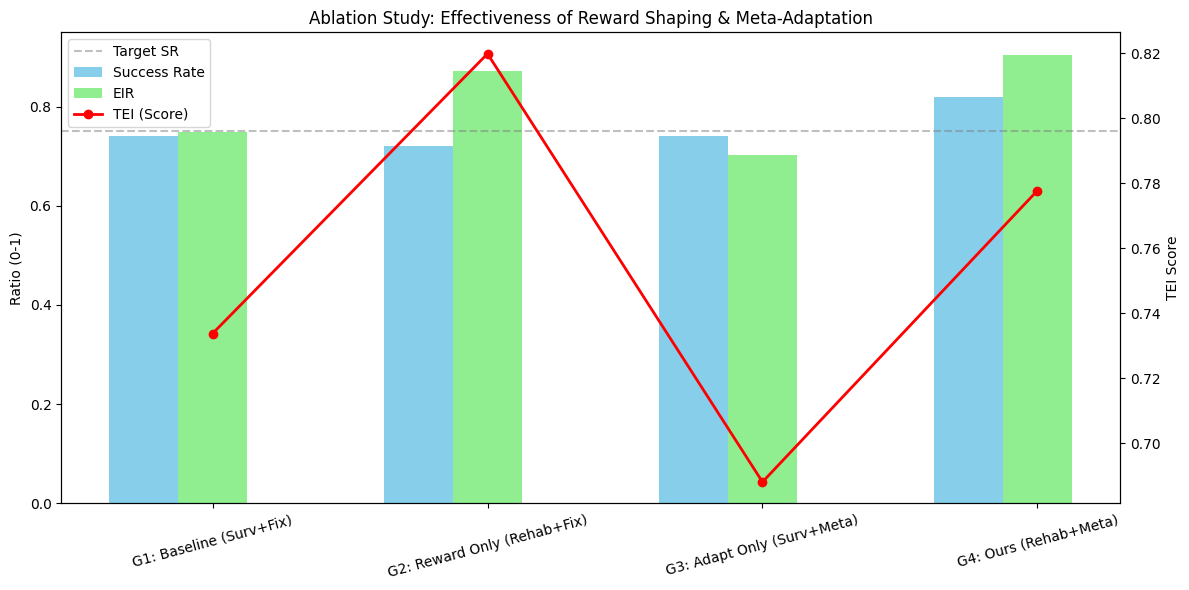

In [8]:
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import SAC
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的环境代码在当前目录下，文件名为 env_v2.py
# 如果报错，请确保 RehabilitationEnv 类定义在这个脚本里或者能被 import


# ==========================================
# 1. 实验配置
# ==========================================

# 模型路径 (请修改为你实际的路径)
PATH_MODEL_SURVIVAL = "logs/robot_stage2/1/best_model.zip" # Baseline Policy
PATH_MODEL_REHAB    = "logs/robot_stage2/14/best_model.zip"    # Ours Policy (Robot Stage 2)
PATH_META_CONTROLLER = "meta_controller.pth"               # Meta Network

# 实验参数
NUM_TEST_PATIENTS = 50   # 测试集病人数量
ASSESSMENT_SPEED = 3.0   # 测评阶段机器人的速度
ASSESSMENT_STEPS = 40    # 测评跑几步

# ZPD 范围 (用于计算 EIR)
ZPD_MIN, ZPD_MAX = 2.0, 6.0

# 设定一个全局随机种子
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 2. 辅助类与函数
# ==========================================

class MetaControllerNet(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def extract_assessment_features(dist_history, hand_vel_history, robot_test_speed):
    """从测评历史提取特征 X"""
    if len(dist_history) == 0: return np.zeros(4)
    
    # 1. 速度比
    mean_hand_v = np.mean(hand_vel_history) if len(hand_vel_history) > 0 else 0
    vel_ratio = mean_hand_v / robot_test_speed
    
    # 2. 平均距离
    mean_dist = np.mean(dist_history)
    
    # 3. 覆盖率 (<3.0)
    coverage = np.sum(np.array(dist_history) < 3.0) / len(dist_history)
    
    # 4. 稳定性 (加速度std)
    if len(hand_vel_history) > 1:
        accels = np.abs(np.diff(hand_vel_history))
        stability = np.std(accels)
    else:
        stability = 0.0
        
    return np.array([vel_ratio, mean_dist, coverage, stability], dtype=np.float32)

def run_experiment_episode(env, model, speed, zpd_range, patient_params):
    """
    运行单局实验并返回指标 (SR, EIR)
    包含严格的环境重置和参数锁定逻辑
    """
    # 1. 彻底重置
    obs, _ = env.reset()
    
    # 2. [核心] 强制覆盖回指定的病人参数
    # 确保每个组面对的是完全相同的病人
    env.patient.params = patient_params.copy()
    env.patient.action_buffer.clear()
    for _ in range(env.patient.action_buffer.maxlen): 
        env.patient.action_buffer.append(np.zeros(2))
    env.patient.t = 0
    
    # 3. 应用设定的速度
    env.stride_robot = speed
    
    done = False
    dists = []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, term, trunc, info = env.step(action)
        dists.append(info['dist'])
        done = term or trunc
    
    # 4. 计算指标
    dists = np.array(dists)
    is_success = 1.0 if term else 0.0
    
    if len(dists) > 0:
        valid_frames = np.sum((dists >= zpd_range[0]) & (dists <= zpd_range[1]))
        eir = valid_frames / len(dists)
    else:
        eir = 0.0
        
    return is_success, eir

# ==========================================
# 3. 准备阶段
# ==========================================

print(">>> Step 1: 构建标准化测试集...")
test_patient_params = []
temp_env = RehabilitationEnv() 

# 收集所有病人的 v_cap 用于计算固定步长组的基准值
all_v_caps = []

for _ in range(NUM_TEST_PATIENTS):
    params = temp_env.patient.reset_randomly()
    test_patient_params.append(params.copy())
    all_v_caps.append(params['v_max'])

# 计算固定步长：所有病人 v_cap 平均值的 1.5 倍
# 逻辑：固定组试图用一个"较快"的速度来应对所有人
FIXED_SPEED_BASELINE = np.mean(all_v_caps) * 1.5
print(f"测试集就绪。Baseline 固定速度设为: {FIXED_SPEED_BASELINE:.2f} cm/s")

print(">>> Step 2: 加载所有模型...")
try:
    # 加载 SAC 模型
    model_survival = SAC.load(PATH_MODEL_SURVIVAL)
    model_rehab = SAC.load(PATH_MODEL_REHAB)
    
    # 加载 Meta-Controller
    meta_net = MetaControllerNet()
    meta_net.load_state_dict(torch.load(PATH_META_CONTROLLER))
    meta_net.eval()
    print("模型加载成功。")
except Exception as e:
    print(f"[Error] 模型加载失败: {e}")
    print("请检查 logs 路径。为了代码能跑通，下面将使用随机策略代替缺失的模型。")
    # 为了演示，如果没模型就用 None (实际跑的时候记得改回来)
    model_survival = model_rehab = None

# 初始化主环境
env = RehabilitationEnv(training_mode='robot', robot_model=None, hand_model=None)

# ==========================================
# 4. 执行消融实验 (The Ablation Loop)
# ==========================================

# 定义 4 个实验组
# (Name, Model, Use_Meta)
# 如果模型加载失败，这里用 model_rehab 代替演示
groups = [
    ("G1: Baseline (Surv+Fix)",  model_survival if model_survival else model_rehab, False),
    ("G2: Reward Only (Rehab+Fix)", model_rehab,    False),
    ("G3: Adapt Only (Surv+Meta)",  model_survival if model_survival else model_rehab, True),
    ("G4: Ours (Rehab+Meta)",       model_rehab,    True),
]

all_results = []

print(">>> Step 3: 开始运行消融对比...")

for group_name, policy_model, use_meta in groups:
    print(f"正在测试: {group_name} ...")
    
    group_sr_list = []
    group_eir_list = []
    
    for params in tqdm(test_patient_params):
        
        # --- A. 确定机器人速度 ---
        if use_meta:
            # 1. 运行测评 (Assessment Phase)
            # 先重置环境，并锁死当前病人参数
            obs, _ = env.reset()
            env.patient.params = params.copy()
            env.patient.action_buffer.clear()
            for _ in range(env.patient.action_buffer.maxlen): 
                env.patient.action_buffer.append(np.zeros(2))
                
            env.stride_robot = ASSESSMENT_SPEED
            
            # 采集数据容器
            hist_dist = []
            hist_vel = []
            
            # 跑测评步数
            for _ in range(ASSESSMENT_STEPS):
                # 测评时使用 Eval 策略 (这里简单用当前策略代替，或专门加载 Eval 模型)
                if policy_model:
                    action, _ = policy_model.predict(obs, deterministic=True)
                else:
                    action = env.action_space.sample()
                
                obs, _, done, _, info = env.step(action)
                
                hist_dist.append(info['dist'])
                if len(env.hand_history_buffer) > 0:
                    v_h = np.linalg.norm(env.hand_history_buffer[-1])
                    hist_vel.append(v_h)
                    
                if done: break
                
            # 2. 提取特征 & 推理
            feats = extract_assessment_features(hist_dist, hist_vel, ASSESSMENT_SPEED)
            
            # 放入网络预测
            with torch.no_grad():
                feats_tensor = torch.FloatTensor(feats).unsqueeze(0)
                predicted_speed = meta_net(feats_tensor).item()
            
            # 限制范围
            final_speed = np.clip(predicted_speed, 0.5, 3.5)
            
        else:
            # 固定步长组
            final_speed = FIXED_SPEED_BASELINE

        # --- B. 运行正式实验 (Therapy Phase) ---
        # 传入当前病人参数、策略模型、确定的速度
        sr, eir = run_experiment_episode(env, policy_model if policy_model else env, final_speed, (ZPD_MIN, ZPD_MAX), params)
        
        group_sr_list.append(sr)
        group_eir_list.append(eir)
        
    # --- C. 统计本组结果 ---
    mean_sr = np.mean(group_sr_list)
    mean_eir = np.mean(group_eir_list)
    # TEI 计算公式: EIR * (1 - beta * |SR - 0.75|)
    # beta 取 2.0
    tei = mean_eir * max(0, 1 - 2.0 * abs(mean_sr - 0.75))
    
    all_results.append({
        "Group": group_name,
        "Success Rate": mean_sr,
        "EIR": mean_eir,
        "TEI": tei
    })

# ==========================================
# 5. 结果展示
# ==========================================
df_results = pd.DataFrame(all_results)
print("\n" + "="*40)
print(" FINAL ABLATION RESULTS ")
print("="*40)
print(df_results)
print("-" * 40)

# 绘图
plt.figure(figsize=(12, 6))

# 双轴图
ax1 = plt.gca()
width = 0.25
x = np.arange(len(df_results))

# 柱状图：SR 和 EIR
rects1 = ax1.bar(x - width, df_results["Success Rate"], width, label='Success Rate', color='skyblue')
rects2 = ax1.bar(x, df_results["EIR"], width, label='EIR', color='lightgreen')

# 折线图：TEI (综合得分)
ax2 = ax1.twinx()
ax2.plot(x, df_results["TEI"], 'r-o', linewidth=2, label='TEI (Score)')

# 标注
ax1.set_ylabel('Ratio (0-1)')
ax2.set_ylabel('TEI Score')
ax1.set_xticks(x)
ax1.set_xticklabels(df_results["Group"], rotation=15)
ax1.axhline(0.75, color='gray', linestyle='--', alpha=0.5, label='Target SR')

# 合并图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("Ablation Study: Effectiveness of Reward Shaping & Meta-Adaptation")
plt.tight_layout()
plt.show()

# 清理
env.close()

In [26]:
from stable_baselines3 import SAC,PPO
# env =DummyVecEnv([lambda: Monitor(CustomEnv())])  # Wrap the environment with Monitor for logging

# env = VecNormalize.load('vec_norm.pkl',env)
# env = VecNormalize(env)  # Apply normalization to the environment
# seed = np.random.randint(0,1000)
# from custom_env import CustomEnv
# env = CustomEnv_hand()
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))
# env.random = False

# env = CustomEnv()
# model_robot= SAC.load("logs/best_model_sac88/best_model.zip",env=env)  # Load the best model

model_hand = SAC.load("logs/hand/1/best_model.zip")  # Load the best model
# # ['healthy', 'parkinson', 'stroke', 'ataxia']
# env = CustomEnv_hand(robot_model=model_robot,hand_mode='stroke')
model_robot = SAC.load("logs/robot_stage2/14/best_model.zip")  # Load the best model
env = RehabilitationEnv(training_mode='robot',robot_model=model_robot,hand_model=None)
env.env_width = 15
obs,_ = env.reset()
env.arm_blocking_length = 3

env.random_epsilon = 0.15

env.stride_hand = 1
env.patient.params['v_max'] = 2







env.stride_robot =2
env.margin = 0.1
env.distance_threshold_collision = 2.5
state_history = []
max_steps = 400
print(obs)
hand_position = obs[2:4]
print(f"hand_position:{hand_position}")
env.bio_filter.mode = 'healthy'
env.random_noise = False
for i in range(max_steps):

    env.hand_position = hand_position
    obs = env._get_obs()
    info = env._get_info()
    
    
    action, _states = model_robot.predict(obs, deterministic=True)

    obs, reward, teminated,_, info = env.step(action)
    state_history.append(obs)
    print(reward)
    # print(f"obs:{obs}")
    # print(f"action:{action}")

    # print('blocking point',env.blocking_point)

    # print(info["robot_position"],info["hand_position"])
    # print("Reward:", reward)
    # print("distance_arm:",info['distance_arm'])
    # env.render()
    hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)
    time.sleep(0.5)  # Control the frame rate
    if teminated:
        render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)


        # env.close()
        break
        print("Resetting environment")
# metric(state_history)
pygame.quit()

[12.170696   4.099096   2.4990356  6.7089343 10.017598  12.170696
  2.829304   4.099096   5.900904   1.7414316  5.250253  10.
  2.4990356  6.7089343  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.       ]
hand_position:[2.4990356 6.7089343]
-5.0
2.868017495853313
9
9
1.8002399596756375
-5.0
-4.06400091364994
9
9
9
9
9
9
9
9
9
3.292219185726398
2.605950200773353
2.1902168017767076
1.577878585158039
3.2075707250803736
9
9
9
2.3516523814950174
1.9394004439048733
1.9382117115187851
9
9
9
9
9
9
1.777770729323331
2.711130113484273
0.5053725190768521
-1.9771259857263708
3.6580749019274665
3.463402602007414
3.700207209815922
1.4919846192594326
3.1294736582879725
9
9
9
3.3650909622962057


SystemExit: 

g:\anaconda\envs\RL\lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Training Meta-Controller...
Epoch 0, Loss: 0.6090
Epoch 10, Loss: 0.2055
Epoch 20, Loss: 0.2073
Epoch 30, Loss: 0.2051
Epoch 40, Loss: 0.2026
Epoch 50, Loss: 0.2052
Epoch 60, Loss: 0.2116
Epoch 70, Loss: 0.2020
Epoch 80, Loss: 0.2076
Epoch 90, Loss: 0.2009
Meta-Controller Trained & Saved!


开始 Block-based ZPD 自适应测试...


Adaptive Blocks: 100%|██████████| 50/50 [00:19<00:00,  2.62it/s]


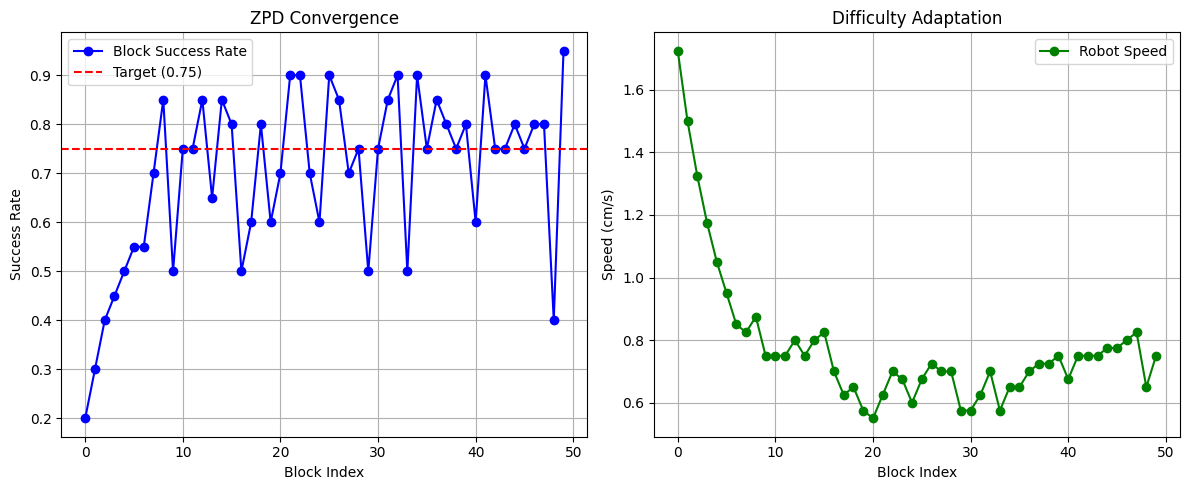

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
from tqdm import tqdm
import pygame

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))

model_robot = SAC.load("logs/robot_stage2/1/best_model.zip")
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=None)

# 实验参数
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 1.5 

# --- 核心变量 ---
env.stride_hand = 0.8          # 病人能力固定
current_robot_speed = 2.0      # 初始机器人速度
target_success_rate = 0.75     # 目标 ZPD 成功率
learning_rate = 0.5            # 调整幅度系数 (Alpha)

epochs = 50       # 总共调整 50 次难度
eval_episodes = 20 # 每次评估跑 20 局

# 记录数据
history_success_rate = []
history_difficulty = []

render = False

print("开始 Block-based ZPD 自适应测试...")

for epoch in tqdm(range(epochs), desc="Adaptive Blocks"):
    success_count = 0
    
    # --- [关键修改 1]：在整个 Block 内锁定难度 ---
    env.stride_robot = current_robot_speed
    
    for episode in range(eval_episodes):
        obs, _ = env.reset()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                env.render()
            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / eval_episodes
    
    # 2. 计算误差 (Error)
    # 如果 rate = 1.0 (太简单), error = +0.25 -> 速度增加
    # 如果 rate = 0.2 (太难), error = -0.55 -> 速度大减
    error = current_rate - target_success_rate
    
    # 3. 比例调整 (P-Control Update)
    # 速度变化量 = 学习率 * 误差
    # 比如: 2.0 + 0.5 * 0.25 = 2.125 (稍微加速)
    # 比如: 2.0 + 0.5 * (-0.55) = 1.725 (大幅减速)
    current_robot_speed += learning_rate * error
    
    # 4. 安全限制
    current_robot_speed = np.clip(current_robot_speed, 0.5, 5.0)
    
    # 记录数据
    history_success_rate.append(current_rate)
    history_difficulty.append(current_robot_speed)

# --- 绘图 ---
plt.figure(figsize=(12, 5))

# 图1: 成功率是否稳定在 0.75
plt.subplot(1, 2, 1)
plt.plot(history_success_rate, 'b-o', label='Block Success Rate')
plt.axhline(y=0.75, color='r', linestyle='--', label='Target (0.75)')
plt.title("ZPD Convergence")
plt.xlabel("Block Index")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)

# 图2: 难度是否找到平衡点
plt.subplot(1, 2, 2)
plt.plot(history_difficulty, 'g-o', label='Robot Speed')
plt.title("Difficulty Adaptation")
plt.xlabel("Block Index")
plt.ylabel("Speed (cm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
env.close()

开始 Block-based ZPD 自适应测试...


Adaptive Blocks: 100%|██████████| 50/50 [03:22<00:00,  4.05s/it]


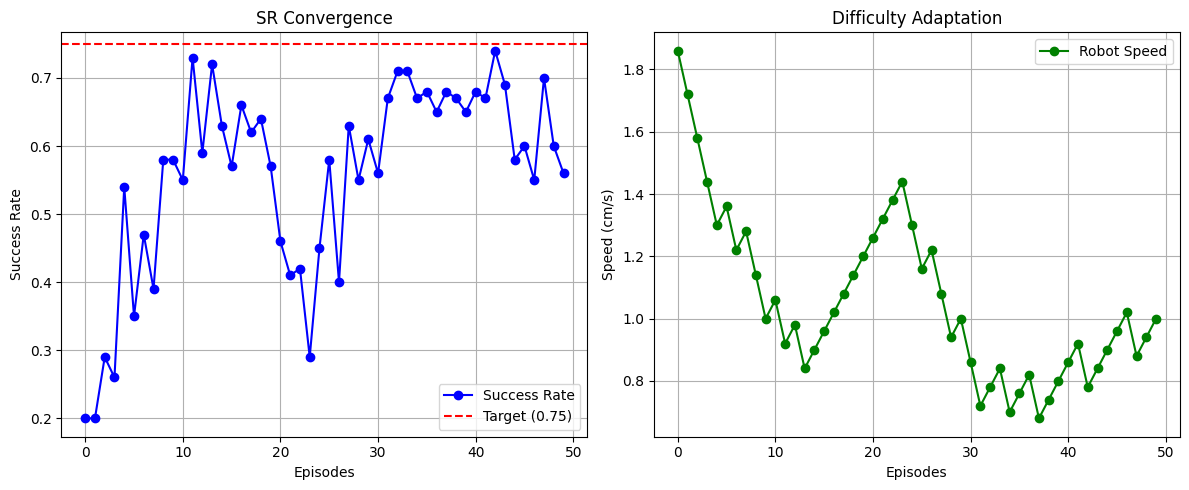

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
from tqdm import tqdm
import pygame

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))

model_robot = SAC.load("logs/robot_stage2/1/best_model.zip")
hand_model = SAC.load("logs/hand/1/best_model.zip")
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 1.5 

# --- 核心变量 ---
env.stride_hand = 0.8          # 病人能力固定
current_robot_speed = 2.0      # 初始机器人速度
target_success_rate = 0.75     # 目标 ZPD 成功率
learning_rate = 0.4            # 调整幅度系数 (Alpha)

epochs = 50       # 总共调整 50 次难度
eval_episodes = 100 # 每次评估跑 20 局

# 记录数据
history_success_rate = []
history_difficulty = []

render = False

print("开始 Block-based ZPD 自适应测试...")

for epoch in tqdm(range(epochs), desc="Adaptive Blocks"):
    success_count = 0
    
    # --- [关键修改 1]：在整个 Block 内锁定难度 ---
    env.stride_robot = current_robot_speed









    


    # 跑一遍 调整速度

    obs, _ = env.reset()
    # 再次确保 reset 没有重置掉我们的设定
    env.stride_robot = current_robot_speed 
    env.stride_hand = 0.8
    
    done = False
    is_success = False
        
    while not done:
        action, _ = model_robot.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        if render:
            env.render()
        
        if terminated: # 抓到了
            is_success = True
            done = True
        elif truncated: # 跑掉了
            is_success = False
            done = True
    
    if is_success:
        current_robot_speed += 0.06
    
    else:
        current_robot_speed -= 0.14



    
    for episode in range(eval_episodes):
        obs, _ = env.reset()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                env.render()
            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / eval_episodes

    
    # 记录数据
    history_success_rate.append(current_rate)
    history_difficulty.append(current_robot_speed)

# --- 绘图 ---
plt.figure(figsize=(12, 5))

# 图1: 成功率是否稳定在 0.75
plt.subplot(1, 2, 1)
plt.plot(history_success_rate, 'b-o', label='Success Rate')
plt.axhline(y=0.75, color='r', linestyle='--', label='Target (0.75)')
plt.title("SR Convergence")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)

# 图2: 难度是否找到平衡点
plt.subplot(1, 2, 2)
plt.plot(history_difficulty, 'g-o', label='Robot Speed')
plt.title("Difficulty Adaptation")
plt.xlabel("Episodes")
plt.ylabel("Speed (cm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
env.close()

开始 Block-based ZPD 自适应测试...


Adaptive Blocks: 100%|██████████| 50/50 [03:24<00:00,  4.09s/it]


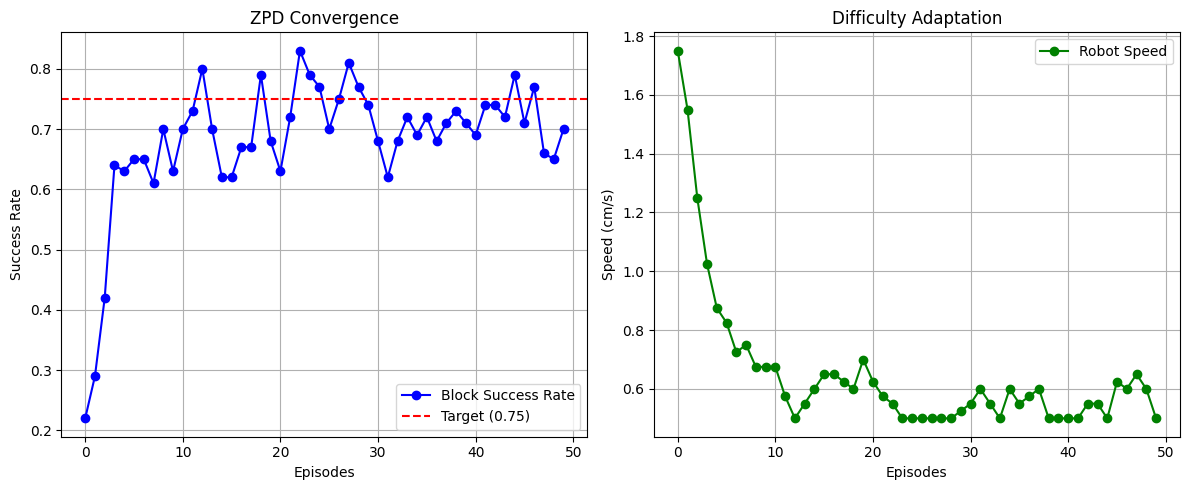

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
from tqdm import tqdm
import pygame

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen = pygame.display.set_mode((int(grid_s * cell_s * 1.5), int(grid_s * cell_s)))

model_robot = SAC.load("logs/robot_stage2/1/best_model.zip")
hand_model = SAC.load("logs/hand/1/best_model.zip")
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 1.5 

# --- 核心变量 ---
env.stride_hand = 0.8          # 病人能力固定
current_robot_speed = 2.0      # 初始机器人速度
target_success_rate = 0.75     # 目标 ZPD 成功率
learning_rate = 0.5            # 调整幅度系数 (Alpha)

epochs = 50       # 总共调整 50 次难度
eval_episodes = 20 # 每次评估跑 20 局

# 记录数据
history_success_rate = []
history_difficulty = []

render = False

print("开始 Block-based ZPD 自适应测试...")




# 设置robot 为固定轨迹


obs, _ = env.reset()
done = False
is_success = False

info_list = []
while not done:
    # action, _ = model_robot.predict(obs, deterministic=True)
    # 固定让robot 横着走
    action = np.array([0.8, 0.0])  # 横向移动
    obs, reward, terminated, truncated, info = env.step(action)

    info_list.append(info['dist'])
    
    if render:
        hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)
    
    if terminated: # 抓到了
        is_success = True
        done = True
    elif truncated: # 跑掉了
        is_success = False
        done = True

if is_success:
    success_count += 1







for epoch in tqdm(range(epochs), desc="Adaptive Blocks"):
    success_count = 0
    
    # --- [关键修改 1]：在整个 Block 内锁定难度 ---
    env.stride_robot = current_robot_speed
    
    for episode in range(eval_episodes):
        obs, _ = env.reset()
        info = env._get_info()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)

            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / eval_episodes
    
    # 2. 计算误差 (Error)
    # 如果 rate = 1.0 (太简单), error = +0.25 -> 速度增加
    # 如果 rate = 0.2 (太难), error = -0.55 -> 速度大减
    error = current_rate - target_success_rate
    
    # 3. 比例调整 (P-Control Update)
    # 速度变化量 = 学习率 * 误差
    # 比如: 2.0 + 0.5 * 0.25 = 2.125 (稍微加速)
    # 比如: 2.0 + 0.5 * (-0.55) = 1.725 (大幅减速)
    current_robot_speed += learning_rate * error
    
    # 4. 安全限制
    current_robot_speed = np.clip(current_robot_speed, 0.5, 5.0)


    success_count = 0


    for episode in range(100):
        obs, _ = env.reset()
        info = env._get_info()
        # 再次确保 reset 没有重置掉我们的设定
        env.stride_robot = current_robot_speed 
        env.stride_hand = 0.8
        
        done = False
        is_success = False
        
        while not done:
            action, _ = model_robot.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                hand_position = render_aesthetic(info["robot_pos"], info["hand_pos"],info["fixed_point"], info["blocking_point"], trajectory_points=env.trajectory_points,width=1.5,window=screen)

            
            if terminated: # 抓到了
                is_success = True
                done = True
            elif truncated: # 跑掉了
                is_success = False
                done = True
        
        if is_success:
            success_count += 1

    # --- [关键修改 2]：Block 结束后，根据统计结果调整 ---
    
    # 1. 计算本轮的真实成功率
    current_rate = success_count / 100
    
    # 记录数据
    history_success_rate.append(current_rate)
    history_difficulty.append(current_robot_speed)

# --- 绘图 ---
plt.figure(figsize=(12, 5))

# 图1: 成功率是否稳定在 0.75
plt.subplot(1, 2, 1)
plt.plot(history_success_rate, 'b-o', label='Block Success Rate')
plt.axhline(y=0.75, color='r', linestyle='--', label='Target (0.75)')
plt.title("ZPD Convergence")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)

# 图2: 难度是否找到平衡点
plt.subplot(1, 2, 2)
plt.plot(history_difficulty, 'g-o', label='Robot Speed')
plt.title("Difficulty Adaptation")
plt.xlabel("Episodes")
plt.ylabel("Speed (cm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
env.close()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
import pygame

# --- 1. 实验设置 ---
# 定义 ZPD (最近发展区) 的距离范围 (单位: Grid/cm)
# 这个范围由你之前的 Reward Function 决定
ZPD_MIN = 3  # 太近了 (危险/已抓到)
ZPD_MAX = 5  # 太远了 (脱离交互)

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen_width = int(grid_s * cell_s * 1.5)
screen_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((screen_width, screen_height))

# 加载模型
# 请确保路径正确
model_path = "logs/robot_stage2/4/best_model.zip" 
try:
    model_robot = SAC.load(model_path)
    print(f"成功加载模型: {model_path}")
except:
    print("模型加载失败，请检查路径。这里使用随机策略演示。")
    model_robot = None

hand_model = SAC.load("logs/hand/1/best_model.zip")

# 创建环境
# 注意：这里我们测试的是 Robot，Hand 用默认脚本即可
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数覆盖
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 2.5  # 抓取判定
env.stride_hand = 0.8                   # 模拟一个中等速度的病人
env.stride_robot = 2.0                  # 设定机器人的能力

render = False  # 是否显示 Pygame 窗口

print(f"开始 ZPD 保持能力测试 (Target Range: {ZPD_MIN} - {ZPD_MAX})...")


global_eir_list = []
global_success_rate_list = []
global_avg_dist_list = []

for i in range(10):
    eir_list = []
    dist_list = []
    success_count = 0
    for episode in range(1000):  # 这里只跑一局测试
    # --- 2. 运行单局测试 ---
        obs, _ = env.reset()
        env.stride_hand = 0.8+0.1*i                   # 模拟一个中等速度的病人
        env.stride_robot = 2.5                  # 设定机器人的能力
        env.distance_threshold_collision = 2.5  # 抓取判定
        env.max_steps = 20
        done = False
        is_success = False

        # 记录器
        history_dist = []
        history_hand_vel = []

        while not done:
            # A. 机器人决策
            if model_robot:
                action, _ = model_robot.predict(obs, deterministic=True)
            else:
                action = env.action_space.sample() # 随机动作作为 fallback

            # B. 环境步进
            obs, reward, terminated, truncated, info = env.step(action)

            # C. 记录数据
            # 计算当前距离 (Info里可能有，也可以自己算)
            current_dist = np.linalg.norm(env.robot_position - env.hand_position)
            history_dist.append(current_dist)
            
            # 记录手部速度 (用于分析机器人是否跟丢了)
            if len(env.hand_history_buffer) > 0:
                hand_v = np.linalg.norm(env.hand_history_buffer[-1])
                history_hand_vel.append(hand_v)

            # D. 渲染
            if render:
                # 这里调用你之前的 render_aesthetic 或者 env 自带的 render
                # 为了通用性，这里调用 env.render()，你可以换回你的 aesthetic 版本
                env.render() 
                # time.sleep(0.05) # 如果太快看不清可以加延时

            # E. 结束判定
            if terminated: # 抓到了
                is_success = True
                success_count += 1
                done = True
                # print("Result: Success (Caught)")
            elif truncated: # 超时/跑掉了
                is_success = False
                done = True
                # print("Result: Timeout/Escaped")

        # --- 3. 计算指标 ---
        dist_array = np.array(history_dist)
        total_frames = len(dist_array)

        # 计算在 ZPD 区间内的帧数
        in_zone_frames = np.sum((dist_array >= ZPD_MIN) & (dist_array <= ZPD_MAX))

        # 计算 EIR (Effective Interaction Ratio)
        eir = in_zone_frames / total_frames if total_frames > 0 else 0


        if total_frames > 5:
            eir_list.append(eir)
            dist_list.append(total_frames)



        # print("-" * 30)
        # print(f"实验报告:")
        # print(f"总时长: {total_frames} 帧")
        # print(f"ZPD 区间: [{ZPD_MIN}, {ZPD_MAX}]")
        # print(f"有效交互比率 (EIR): {eir * 100:.2f}%")
        # print("-" * 30)

        # --- 4. 绘图分析 (论文图表) ---
        # plt.figure(figsize=(10, 5))

        # # 绘制距离曲线
        # plt.plot(dist_array, label='Real-time Distance', color='#2980b9', linewidth=2)

        # # 绘制 ZPD 区域 (绿色背景带)
        # plt.axhspan(ZPD_MIN, ZPD_MAX, color='#2ecc71', alpha=0.2, label='ZPD (Optimal Zone)')

        # # 绘制危险区 (红色背景带 - 太近)
        # plt.axhspan(0, ZPD_MIN, color='#e74c3c', alpha=0.1, label='Too Close (<2.0)')

        # # 绘制脱离区 (灰色背景带 - 太远)
        # # 假设最大显示距离为 15
        # plt.axhspan(ZPD_MAX, 15, color='#95a5a6', alpha=0.1, label='Too Far (>6.0)')

        # # 标注平均距离
        # mean_dist = np.mean(dist_array)
        # plt.axhline(y=mean_dist, color='#e67e22', linestyle='--', label=f'Mean Dist: {mean_dist:.2f}')

        # plt.title(f'Robot Capability to Maintain ZPD (EIR: {eir*100:.1f}%)')
        # plt.xlabel('Time Step')
        # plt.ylabel('Distance (Grid Units)')
        # plt.legend(loc='upper right')
        # plt.grid(True, alpha=0.3)
        # plt.ylim(0, 12) # 固定 Y 轴范围方便观察

        # plt.tight_layout()
        # plt.show()

        # 关闭环境
        env.close()

    # print("=== 总结报告 ===")
    # print(f"平均有效交互比率 (EIR) over 100 episodes: {np.mean(eir_list) * 100:.2f}%")
    # print(f"成功率: {success_count / 10:.2f}%")
    global_eir_list.append(np.mean(eir_list).item())
    global_success_rate_list.append(success_count / 1000)
    global_avg_dist_list.append(np.mean(dist_list))

print("=== 全局总结报告 ===")
print(global_eir_list)
print(global_success_rate_list)



成功加载模型: logs/robot_stage2/4/best_model.zip
开始 ZPD 保持能力测试 (Target Range: 3 - 5)...
=== 全局总结报告 ===
[0.5162989849457612, 0.526947105058036, 0.5515158163679759, 0.5562316666863854, 0.5474761623357621, 0.5584180976540909, 0.5527502512591037, 0.5397400538134012, 0.5297969009239549, 0.5223486858202093]
[0.65, 0.737, 0.772, 0.788, 0.789, 0.819, 0.831, 0.819, 0.856, 0.838]


In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
import pygame

# --- 1. 实验设置 ---
# 定义 ZPD (最近发展区) 的距离范围 (单位: Grid/cm)
# 这个范围由你之前的 Reward Function 决定
ZPD_MIN = 3  # 太近了 (危险/已抓到)
ZPD_MAX = 5  # 太远了 (脱离交互)

# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen_width = int(grid_s * cell_s * 1.5)
screen_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((screen_width, screen_height))

# 加载模型
# 请确保路径正确
model_path = "logs/robot_stage2/5/best_model.zip" 
try:
    model_robot = SAC.load(model_path)
    print(f"成功加载模型: {model_path}")
except:
    print("模型加载失败，请检查路径。这里使用随机策略演示。")
    model_robot = None

hand_model = SAC.load("logs/hand/1/best_model.zip")
# 创建环境
# 注意：这里我们测试的是 Robot，Hand 用默认脚本即可
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数覆盖
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 2.5  # 抓取判定
env.stride_hand = 0.8                   # 模拟一个中等速度的病人
env.stride_robot = 2.0                  # 设定机器人的能力

render = False  # 是否显示 Pygame 窗口

print(f"开始 ZPD 保持能力测试 (Target Range: {ZPD_MIN} - {ZPD_MAX})...")


global_eir_list2 = []
global_success_rate_list2 = []
global_avg_dist_list2 = []

for i in range(10):
    eir_list = []
    success_count = 0
    dist_list = []
    for episode in range(1000):  # 这里只跑一局测试
    # --- 2. 运行单局测试 ---
        obs, _ = env.reset()
        env.stride_hand = 0.8+0.1*i                   # 模拟一个中等速度的病人
        env.stride_robot = 2.5                  # 设定机器人的能力
        env.distance_threshold_collision = 2.5  # 抓取判定
        env.max_steps = 20
        done = False
        is_success = False

        # 记录器
        history_dist = []
        history_hand_vel = []

        while not done:
            # A. 机器人决策
            if model_robot:
                action, _ = model_robot.predict(obs, deterministic=True)
            else:
                action = env.action_space.sample() # 随机动作作为 fallback

            # B. 环境步进
            obs, reward, terminated, truncated, info = env.step(action)

            # C. 记录数据
            # 计算当前距离 (Info里可能有，也可以自己算)
            current_dist = np.linalg.norm(env.robot_position - env.hand_position)
            history_dist.append(current_dist)
            
            # 记录手部速度 (用于分析机器人是否跟丢了)
            if len(env.hand_history_buffer) > 0:
                hand_v = np.linalg.norm(env.hand_history_buffer[-1])
                history_hand_vel.append(hand_v)

            # D. 渲染
            if render:
                # 这里调用你之前的 render_aesthetic 或者 env 自带的 render
                # 为了通用性，这里调用 env.render()，你可以换回你的 aesthetic 版本
                env.render() 
                # time.sleep(0.05) # 如果太快看不清可以加延时

            # E. 结束判定
            if terminated: # 抓到了
                is_success = True
                success_count += 1
                done = True
                # print("Result: Success (Caught)")
            elif truncated: # 超时/跑掉了
                is_success = False
                done = True
                # print("Result: Timeout/Escaped")

        # --- 3. 计算指标 ---
        dist_array = np.array(history_dist)
        total_frames = len(dist_array)

        # 计算在 ZPD 区间内的帧数
        in_zone_frames = np.sum((dist_array >= ZPD_MIN) & (dist_array <= ZPD_MAX))

        # 计算 EIR (Effective Interaction Ratio)
        eir = in_zone_frames / total_frames if total_frames > 0 else 0


        if total_frames > 5:
            eir_list.append(eir)
            dist_list.append(total_frames)



        # print("-" * 30)
        # print(f"实验报告:")
        # print(f"总时长: {total_frames} 帧")
        # print(f"ZPD 区间: [{ZPD_MIN}, {ZPD_MAX}]")
        # print(f"有效交互比率 (EIR): {eir * 100:.2f}%")
        # print("-" * 30)

        # --- 4. 绘图分析 (论文图表) ---
        # plt.figure(figsize=(10, 5))

        # # 绘制距离曲线
        # plt.plot(dist_array, label='Real-time Distance', color='#2980b9', linewidth=2)

        # # 绘制 ZPD 区域 (绿色背景带)
        # plt.axhspan(ZPD_MIN, ZPD_MAX, color='#2ecc71', alpha=0.2, label='ZPD (Optimal Zone)')

        # # 绘制危险区 (红色背景带 - 太近)
        # plt.axhspan(0, ZPD_MIN, color='#e74c3c', alpha=0.1, label='Too Close (<2.0)')

        # # 绘制脱离区 (灰色背景带 - 太远)
        # # 假设最大显示距离为 15
        # plt.axhspan(ZPD_MAX, 15, color='#95a5a6', alpha=0.1, label='Too Far (>6.0)')

        # # 标注平均距离
        # mean_dist = np.mean(dist_array)
        # plt.axhline(y=mean_dist, color='#e67e22', linestyle='--', label=f'Mean Dist: {mean_dist:.2f}')

        # plt.title(f'Robot Capability to Maintain ZPD (EIR: {eir*100:.1f}%)')
        # plt.xlabel('Time Step')
        # plt.ylabel('Distance (Grid Units)')
        # plt.legend(loc='upper right')
        # plt.grid(True, alpha=0.3)
        # plt.ylim(0, 12) # 固定 Y 轴范围方便观察

        # plt.tight_layout()
        # plt.show()

        # 关闭环境
        env.close()

    # print("=== 总结报告 ===")
    # print(f"平均有效交互比率 (EIR) over 100 episodes: {np.mean(eir_list) * 100:.2f}%")
    # print(f"成功率: {success_count / 10:.2f}%")
    global_eir_list2.append(np.mean(eir_list).item())
    global_success_rate_list2.append(success_count / 1000)
    global_avg_dist_list2.append(np.mean(dist_list).item())

print("=== 全局总结报告 ===")
print(global_eir_list2)
print(global_success_rate_list2)

成功加载模型: logs/robot_stage2/5/best_model.zip
开始 ZPD 保持能力测试 (Target Range: 3 - 5)...
=== 全局总结报告 ===
[0.6711417352043282, 0.6753051622287477, 0.6806043869231583, 0.6678358484043302, 0.6642808896347153, 0.6485691857933008, 0.6336900564129351, 0.6313514033457274, 0.6129458463164906, 0.6064411248695671]
[0.428, 0.505, 0.525, 0.599, 0.636, 0.681, 0.694, 0.73, 0.734, 0.742]


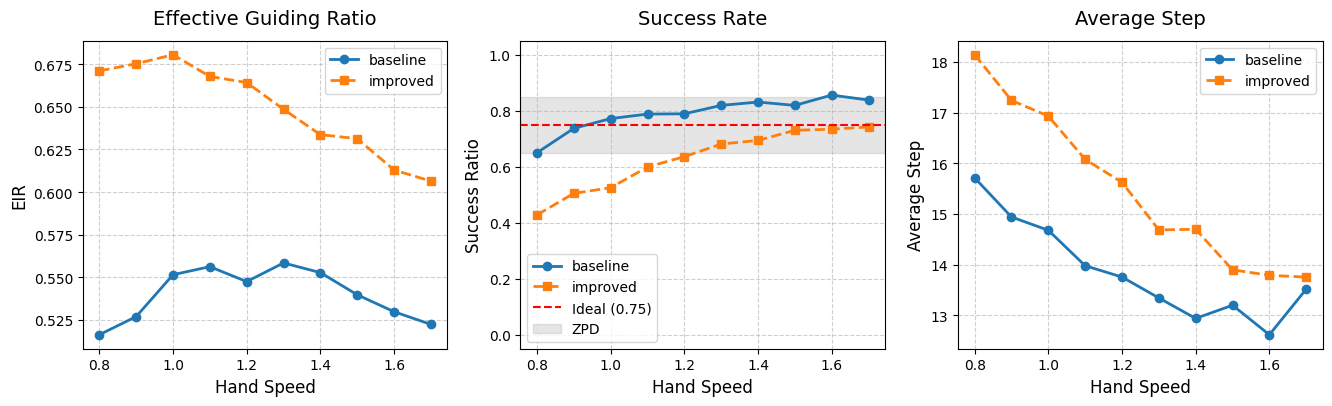

In [ ]:
from matplotlib import pyplot as plt

# 假设 x 轴数据 (如果你的数据长度不一定是10，可以用 len(global_eir_list) 代替)
x_data = [0.8 + 0.1*i for i in range(10)]

# 设置画布大小
plt.figure(figsize=(16, 4))

# ==========================================
# 图1: EIR 对比
# ==========================================
plt.subplot(1, 3, 1)

# Model 1 (蓝色圆点实线)
plt.plot(x_data, global_eir_list, 
         color='tab:blue', marker='o', linestyle='-', linewidth=2, 
         label='baseline') # 建议改成具体模型名字，如 'Baseline'

# Model 2 (橙色方块虚线) - 换颜色和形状以区分
plt.plot(x_data, global_eir_list2, 
         color='tab:orange', marker='s', linestyle='--', linewidth=2, 
         label='improved') # 建议改成具体模型名字，如 'Ours'

plt.title("Effective Guiding Ratio", fontsize=14,pad=12)
plt.xlabel("Hand Speed", fontsize=12)
plt.ylabel("EIR", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # 网格线弄淡一点
plt.legend(fontsize=10) # 显示图例

# ==========================================
# 图2: 成功率对比
# ==========================================
plt.subplot(1, 3, 2)


# global_success_rate_list = [x*100 for x in global_success_rate_list]
# global_success_rate_list2 = [x*100 for x in global_success_rate_list2]
# Model 1
plt.plot(x_data, global_success_rate_list, 
         color='tab:blue', marker='o', linestyle='-', linewidth=2, 
         label='baseline')

# Model 2
plt.plot(x_data, global_success_rate_list2, 
         color='tab:orange', marker='s', linestyle='--', linewidth=2, 
         label='improved')
plt.axhline(y=0.75, color='r', linestyle='--', label='Ideal (0.75)')

plt.axhspan(ymin=0.65, ymax=0.85, color='gray', alpha=0.2, label='ZPD')

plt.title("Success Rate", fontsize=14, pad=12)
plt.xlabel("Hand Speed", fontsize=12)
plt.ylabel("Success Ratio", fontsize=12)
# 如果成功率是0-1之间，可以固定Y轴范围让对比更明显
plt.ylim(-0.05, 1.05) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)


# 距离对比图
plt.subplot(1, 3, 3)
plt.plot(x_data, global_avg_dist_list, color='tab:blue', marker='o', linestyle='-', linewidth=2, label='baseline')
plt.plot(x_data, global_avg_dist_list2, color='tab:orange', marker='s', linestyle='--', linewidth=2, label='improved')

plt.title("Average Step", fontsize=14, pad=12)
plt.xlabel("Hand Speed", fontsize=12)
plt.ylabel("Average Step", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)



# 自动调整布局防止重叠
# plt.tight_layout(pad=4.0, h_pad=4.0, w_pad=3.0)
plt.show()

In [ ]:
import numpy as np
from stable_baselines3 import SAC
from matplotlib import pyplot as plt
import pygame



# --- 初始化 ---
pygame.init()
grid_s = 10
cell_s = 50
screen_width = int(grid_s * cell_s * 1.5)
screen_height = int(grid_s * cell_s)
screen = pygame.display.set_mode((screen_width, screen_height))

# 加载模型
# 请确保路径正确
model_path = "logs/robot_stage2/4/best_model.zip" 
try:
    model_robot = SAC.load(model_path)
    print(f"成功加载模型: {model_path}")
except:
    print("模型加载失败，请检查路径。这里使用随机策略演示。")
    model_robot = None

hand_model = SAC.load("logs/hand/1/best_model.zip")
# 创建环境
# 注意：这里我们测试的是 Robot，Hand 用默认脚本即可
env = RehabilitationEnv(training_mode='robot', robot_model=model_robot, hand_model=hand_model)

# 实验参数覆盖
env.arm_blocking_length = 4
env.env_width = 15
env.random_epsilon = 0.1
env.arm_blocking_ratio = 0.5
env.distance_threshold_collision = 2.5  # 抓取判定
env.stride_hand = 0.8                   # 模拟一个中等速度的病人
env.stride_robot = 2.0                  # 设定机器人的能力

render = False  # 是否显示 Pygame 窗口

print(f"开始 ZPD 保持能力测试 (Target Range: {ZPD_MIN} - {ZPD_MAX})...")


global_eir_list2 = []
global_success_rate_list2 = []
global_avg_dist_list2 = []

for i in range(10):
    eir_list = []
    success_count = 0

    dist_list = []
    hand_vel_list = []
    for episode in range(10):  # 这里只跑一局测试
    # --- 2. 运行单局测试 ---
        obs, _ = env.reset()
        env.stride_hand = 0.5+0.05*i                   # 模拟一个中等速度的病人
        env.stride_robot = 3                  # 设定机器人的能力
        env.distance_threshold_collision = 2.5  # 抓取判定
        env.max_steps = 20
        done = False
        is_success = False

        # 记录器
        history_dist = []
        history_hand_vel = []

        while not done:
            # A. 机器人决策
            if model_robot:
                action, _ = model_robot.predict(obs, deterministic=True)
            else:
                action = env.action_space.sample() # 随机动作作为 fallback

            # B. 环境步进
            obs, reward, terminated, truncated, info = env.step(action)

            # C. 记录数据
            # 计算当前距离 (Info里可能有，也可以自己算)
            current_dist = np.linalg.norm(env.robot_position - env.hand_position)
            history_dist.append(current_dist)
            
            # 记录手部速度 (用于分析机器人是否跟丢了)
            if len(env.hand_history_buffer) > 0:
                hand_v = np.linalg.norm(env.hand_history_buffer[-1])
                history_hand_vel.append(hand_v)

            # D. 渲染
            if render:
                # 这里调用你之前的 render_aesthetic 或者 env 自带的 render
                # 为了通用性，这里调用 env.render()，你可以换回你的 aesthetic 版本
                env.render() 
                # time.sleep(0.05) # 如果太快看不清可以加延时

            # E. 结束判定
            if terminated: # 抓到了
                is_success = True
                success_count += 1
                done = True
                # print("Result: Success (Caught)")
            elif truncated: # 超时/跑掉了
                is_success = False
                done = True
                # print("Result: Timeout/Escaped")

        # --- 3. 计算指标 ---
        dist_array = np.array(history_dist)
        total_frames = len(dist_array)
        



        if total_frames > 5:
            eir_list.append(eir)
            dist_list.append(total_frames)

        dist_list.append(np.mean(dist_array).item())
        hand_vel_list.append(np.mean(history_hand_vel).item())

        # print("-" * 30)
        # print(f"实验报告:")
        # print(f"总时长: {total_frames} 帧")
        # print(f"ZPD 区间: [{ZPD_MIN}, {ZPD_MAX}]")
        # print(f"有效交互比率 (EIR): {eir * 100:.2f}%")
        # print("-" * 30)

        # --- 4. 绘图分析 (论文图表) ---
        # plt.figure(figsize=(10, 5))

        # # 绘制距离曲线
        # plt.plot(dist_array, label='Real-time Distance', color='#2980b9', linewidth=2)

        # # 绘制 ZPD 区域 (绿色背景带)
        # plt.axhspan(ZPD_MIN, ZPD_MAX, color='#2ecc71', alpha=0.2, label='ZPD (Optimal Zone)')

        # # 绘制危险区 (红色背景带 - 太近)
        # plt.axhspan(0, ZPD_MIN, color='#e74c3c', alpha=0.1, label='Too Close (<2.0)')

        # # 绘制脱离区 (灰色背景带 - 太远)
        # # 假设最大显示距离为 15
        # plt.axhspan(ZPD_MAX, 15, color='#95a5a6', alpha=0.1, label='Too Far (>6.0)')

        # # 标注平均距离
        # mean_dist = np.mean(dist_array)
        # plt.axhline(y=mean_dist, color='#e67e22', linestyle='--', label=f'Mean Dist: {mean_dist:.2f}')

        # plt.title(f'Robot Capability to Maintain ZPD (EIR: {eir*100:.1f}%)')
        # plt.xlabel('Time Step')
        # plt.ylabel('Distance (Grid Units)')
        # plt.legend(loc='upper right')
        # plt.grid(True, alpha=0.3)
        # plt.ylim(0, 12) # 固定 Y 轴范围方便观察

        # plt.tight_layout()
        # plt.show()

        # 关闭环境
        env.close()


    print(f"平均距离: {np.mean(dist_list):.2f}")
    print(f"平均手部速度: {np.mean(hand_vel_list):.2f}")



成功加载模型: logs/robot_stage2/4/best_model.zip
开始 ZPD 保持能力测试 (Target Range: 3 - 5)...
平均距离: 9.83
平均手部速度: 0.50
平均距离: 9.28
平均手部速度: 0.55
平均距离: 7.66
平均手部速度: 0.57
平均距离: 9.38
平均手部速度: 0.52
平均距离: 9.39
平均手部速度: 0.68
平均距离: 8.81
平均手部速度: 0.60
平均距离: 7.96
平均手部速度: 0.57
平均距离: 7.10
平均手部速度: 0.75
平均距离: 9.43
平均手部速度: 0.73
平均距离: 6.76
平均手部速度: 0.88


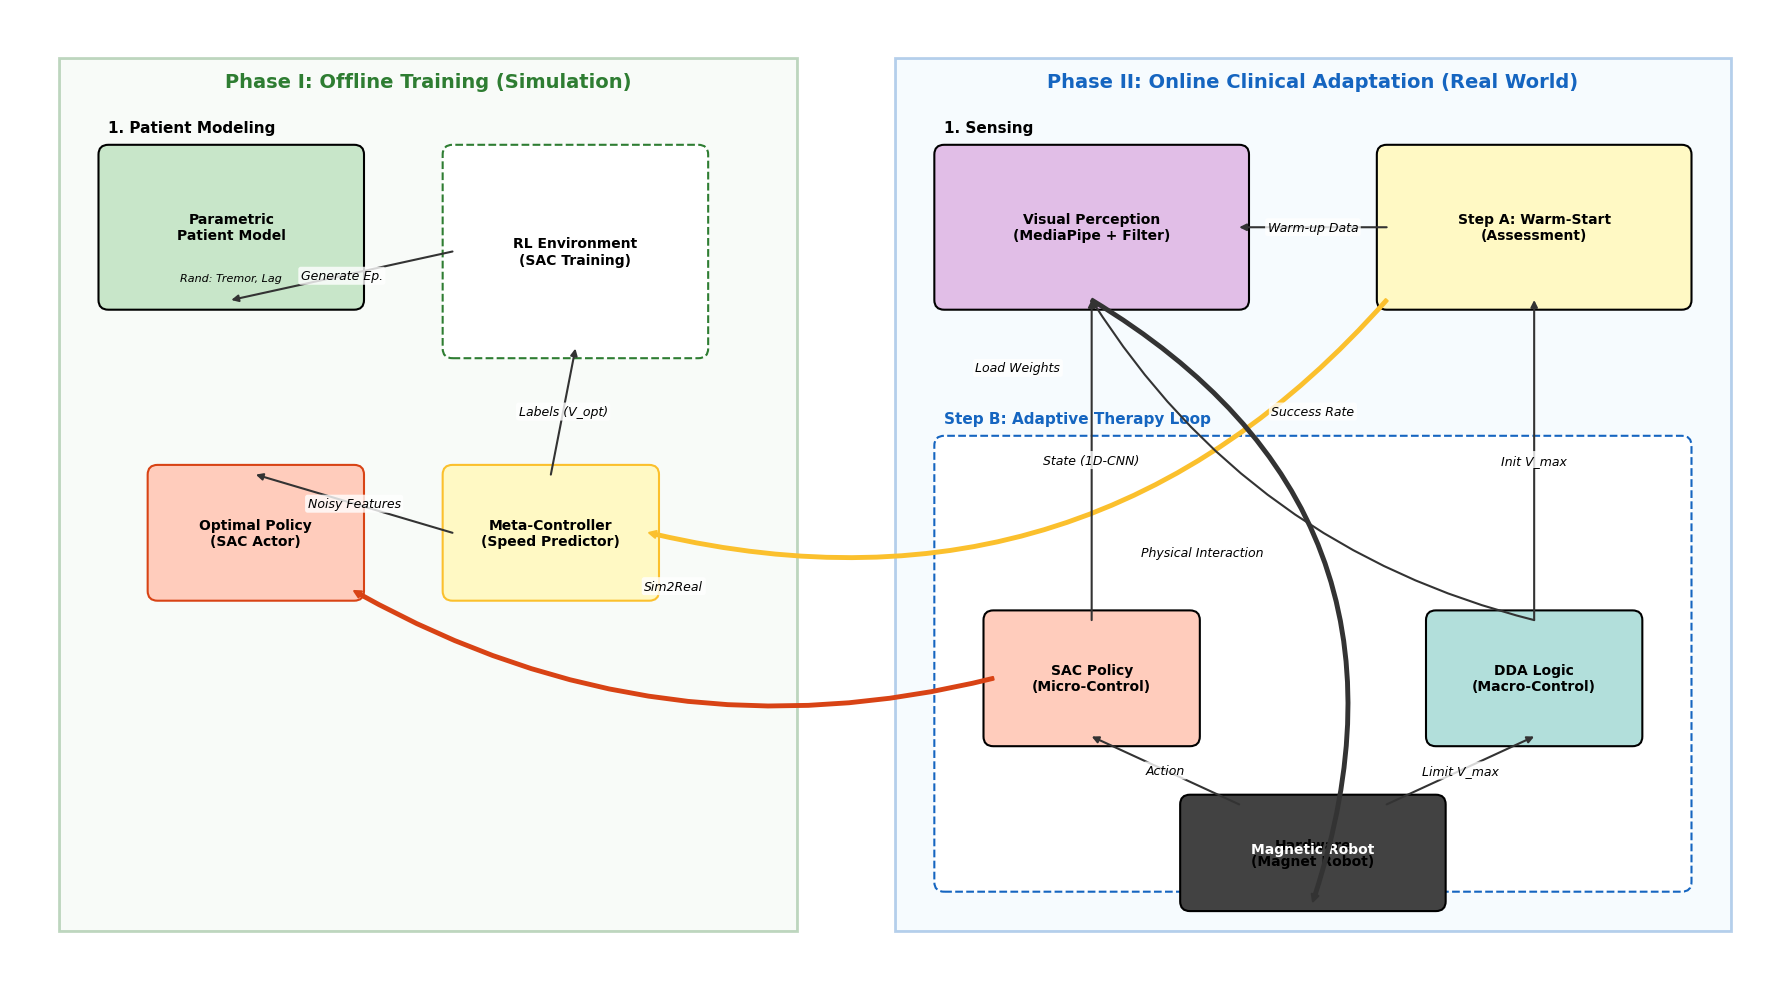

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_algorithm_architecture():
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # --- 绘图辅助函数 ---
    def add_box(x, y, w, h, text, color='white', edge='black', style='-', fontsize=10, zorder=2, title=None):
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", 
                                      linewidth=1.5, edgecolor=edge, facecolor=color, linestyle=style, zorder=zorder)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=zorder+1)
        if title:
            ax.text(x, y + h + 0.2, title, ha='left', va='bottom', fontsize=11, fontweight='bold', color=edge)
        return rect

    def add_arrow(x1, y1, x2, y2, text=None, curved=0, color="#333333", style="-|>"):
        conn = patches.ConnectionPatch(xyA=(x2, y2), xyB=(x1, y1), coordsA="data", coordsB="data",
                                       axesA=ax, axesB=ax, connectionstyle=f"arc3,rad={curved}", 
                                       arrowstyle=style, color=color, linewidth=1.5, zorder=10)
        ax.add_artist(conn)
        if text:
            mid_x = (x1 + x2) / 2
            mid_y = (y1 + y2) / 2 + (0.5 if curved else 0)
            bbox = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
            ax.text(mid_x, mid_y, text, ha='center', va='center', fontsize=9, style='italic', bbox=bbox, zorder=11)

    # ================= 区域划分 =================
    # 左侧：离线训练 (Offline Simulation)
    rect_sim = patches.Rectangle((0.5, 0.5), 7.5, 9.0, linewidth=2, edgecolor='#2E7D32', facecolor='#E8F5E9', alpha=0.3, zorder=0)
    ax.add_patch(rect_sim)
    ax.text(4.25, 9.2, "Phase I: Offline Training (Simulation)", ha='center', fontsize=14, fontweight='bold', color='#2E7D32')

    # 右侧：在线控制 (Online Adaptation)
    rect_real = patches.Rectangle((9.0, 0.5), 8.5, 9.0, linewidth=2, edgecolor='#1565C0', facecolor='#E3F2FD', alpha=0.3, zorder=0)
    ax.add_patch(rect_real)
    ax.text(13.25, 9.2, "Phase II: Online Clinical Adaptation (Real World)", ha='center', fontsize=14, fontweight='bold', color='#1565C0')

    # ================= 左侧内容：训练流水线 =================
    
    # 1. 患者生成模块
    add_box(1.0, 7.0, 2.5, 1.5, "Parametric\nPatient Model", color='#C8E6C9', title="1. Patient Modeling")
    ax.text(2.25, 7.2, "Rand: Tremor, Lag", ha='center', fontsize=8, style='italic')

    # 2. 训练循环 (Loop)
    add_box(4.5, 6.5, 2.5, 2.0, "RL Environment\n(SAC Training)", color='#FFFFFF', edge='#2E7D32', style='--')
    
    # 3. 两个产出模型
    policy_box = add_box(1.5, 4.0, 2.0, 1.2, "Optimal Policy\n(SAC Actor)", color='#FFCCBC', edge='#D84315')
    meta_box = add_box(4.5, 4.0, 2.0, 1.2, "Meta-Controller\n(Speed Predictor)", color='#FFF9C4', edge='#FBC02D')

    # 4. 数据工厂逻辑
    add_arrow(2.25, 7.0, 4.5, 7.5, text="Generate Ep.")
    add_arrow(5.75, 6.5, 5.5, 5.2, text="Labels (V_opt)")
    add_arrow(2.5, 5.2, 4.5, 4.6, text="Noisy Features") # Features -> Meta

    # ================= 右侧内容：在线闭环 =================

    # 1. 视觉感知
    vis_box = add_box(9.5, 7.0, 3.0, 1.5, "Visual Perception\n(MediaPipe + Filter)", color='#E1BEE7', title="1. Sensing")
    
    # 2. 热启动流程 (Warm Start)
    add_arrow(12.5, 7.75, 14.0, 7.75, text="Warm-up Data")
    warm_box = add_box(14.0, 7.0, 3.0, 1.5, "Step A: Warm-Start\n(Assessment)", color='#FFF9C4')
    # 把左边的 Meta 模型传过来
    add_arrow(6.5, 4.6, 14.0, 7.0, text="Load Weights", curved=-0.3, color="#FBC02D", style="simple")

    # 3. 实时控制流程 (Real-time Control)
    ctrl_container = add_box(9.5, 1.0, 7.5, 4.5, "", color='white', edge='#1565C0', style='--', title="Step B: Adaptive Therapy Loop")
    
    # 内环
    sac_real = add_box(10.0, 2.5, 2.0, 1.2, "SAC Policy\n(Micro-Control)", color='#FFCCBC')
    # 把左边的 SAC 模型传过来
    add_arrow(3.5, 4.0, 10.0, 3.1, text="Sim2Real", curved=-0.2, color="#D84315", style="simple")

    # 外环
    dda_box = add_box(14.5, 2.5, 2.0, 1.2, "DDA Logic\n(Macro-Control)", color='#B2DFDB')

    # 硬件执行 - [修复了这个调用]
    hw_box = add_box(12.0, 0.8, 2.5, 1.0, "Hardware\n(Magnet Robot)", color='#424242')
    ax.text(13.25, 1.3, "Magnetic Robot", ha='center', color='white', fontweight='bold')

    # ================= 关键连线 =================
    
    # 视觉 -> 内环 (实时状态)
    add_arrow(11.0, 7.0, 11.0, 3.7, text="State (1D-CNN)")
    
    # 视觉 -> 外环 (成功率)
    add_arrow(11.0, 7.0, 15.5, 3.7, text="Success Rate", curved=-0.2)

    # 热启动 -> 外环 (初始速度)
    add_arrow(15.5, 7.0, 15.5, 3.7, text="Init V_max")

    # 内环 -> 硬件
    add_arrow(11.0, 2.5, 12.5, 1.8, text="Action")
    
    # 外环 -> 硬件 (限制)
    add_arrow(15.5, 2.5, 14.0, 1.8, text="Limit V_max")

    # 硬件 -> 视觉 (闭环)
    add_arrow(13.25, 0.8, 11.0, 7.0, text="Physical Interaction", curved=-0.4, style="simple")

    plt.tight_layout()
    plt.savefig('algorithm_architecture_v2.png', dpi=300, bbox_inches='tight')
    plt.show()

# 运行
draw_algorithm_architecture()

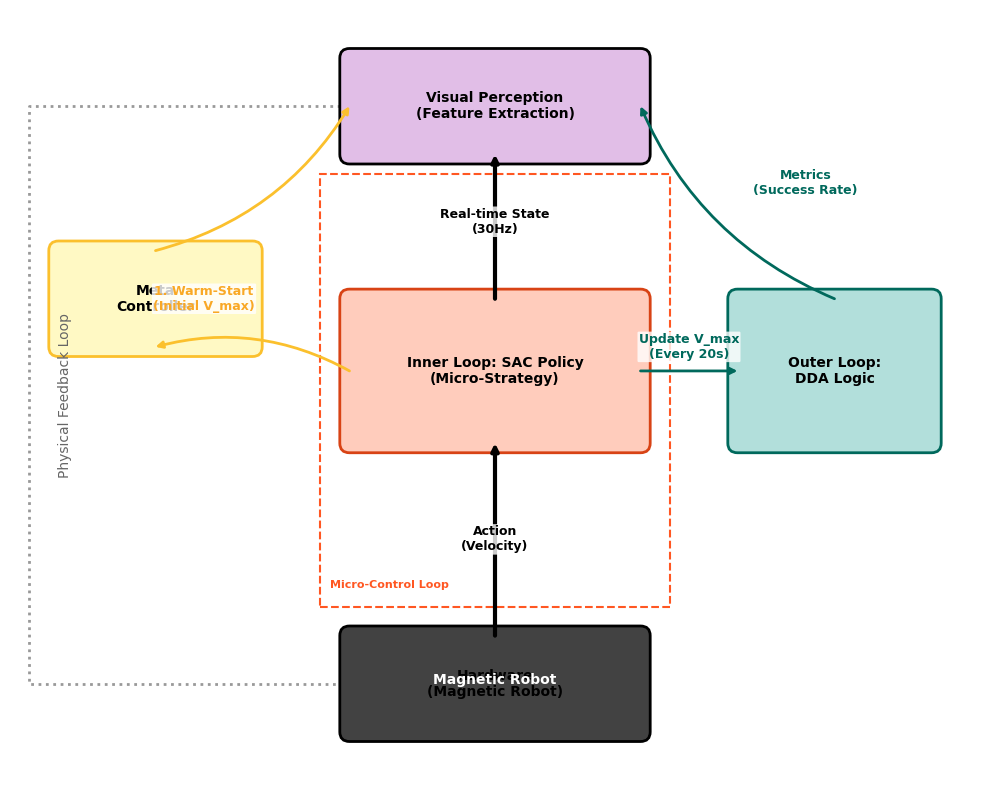

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_dual_loop_control():
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # --- 辅助函数 ---
    def add_box(x, y, w, h, text, color='white', edge='black', style='-', fontsize=10, zorder=2):
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", 
                                      linewidth=2, edgecolor=edge, facecolor=color, linestyle=style, zorder=zorder)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=zorder+1)
        return rect

    def add_arrow(x1, y1, x2, y2, style="-|>", color="black", lw=2, connection="arc3,rad=0"):
        conn = patches.ConnectionPatch(xyA=(x2, y2), xyB=(x1, y1), coordsA="data", coordsB="data",
                                       axesA=ax, axesB=ax, arrowstyle=style, color=color, linewidth=lw,
                                       connectionstyle=connection, zorder=10)
        ax.add_artist(conn)

    def add_label(x, y, text, color='black', bg='white'):
        bbox = dict(boxstyle="round,pad=0.1", fc=bg, ec="none", alpha=0.8)
        ax.text(x, y, text, ha='center', va='center', fontsize=9, color=color, bbox=bbox, fontweight='bold', zorder=12)

    # ================= 1. 上层：感知 (Perception) =================
    vis_box = add_box(3.5, 6.5, 3.0, 1.0, "Visual Perception\n(Feature Extraction)", color='#E1BEE7')

    # ================= 2. 中层：控制 (Controller) =================
    
    # Meta-Controller (Warm-up) - 放在左边，表示一次性注入
    meta_box = add_box(0.5, 4.5, 2.0, 1.0, "Meta\nController", color='#FFF9C4', edge='#FBC02D')
    
    # Inner Loop Core (SAC) - 放在正中间
    sac_box = add_box(3.5, 3.5, 3.0, 1.5, "Inner Loop: SAC Policy\n(Micro-Strategy)", color='#FFCCBC', edge='#D84315')

    # Outer Loop Core (DDA) - 放在右边，形成包围之势
    dda_box = add_box(7.5, 3.5, 2.0, 1.5, "Outer Loop:\nDDA Logic", color='#B2DFDB', edge='#00695C')

    # ================= 3. 下层：执行 (Actuation) =================
    hw_box = add_box(3.5, 0.5, 3.0, 1.0, "Hardware\n(Magnetic Robot)", color='#424242')
    ax.text(5.0, 1.0, "Magnetic Robot", ha='center', color='white', fontweight='bold', zorder=5)

    # ================= 4. 连线逻辑 (The Loops) =================

    # --- Path A: Warm-up (初始化) ---
    add_arrow(3.5, 7.0, 1.5, 5.5, connection="arc3,rad=0.2", color="#FBC02D") # Vis -> Meta
    add_arrow(1.5, 4.5, 3.5, 4.25, connection="arc3,rad=0.2", color="#FBC02D") # Meta -> SAC
    add_label(2.0, 5.0, "1. Warm-Start\n(Initial V_max)", color="#F9A825")

    # --- Path B: Inner Loop (快) ---
    # Vis -> SAC
    add_arrow(5.0, 6.5, 5.0, 5.0, lw=3) 
    add_label(5.0, 5.8, "Real-time State\n(30Hz)")
    
    # SAC -> Hardware
    add_arrow(5.0, 3.5, 5.0, 1.5, lw=3)
    add_label(5.0, 2.5, "Action\n(Velocity)")
    
    # Hardware -> Vis (闭环)
    # 用一条很长的虚线表示物理世界的反馈
    ax.plot([3.5, 0.2, 0.2, 3.5], [1.0, 1.0, 7.0, 7.0], color='#999999', linestyle=':', lw=2, zorder=0)
    ax.text(0.5, 4.0, "Physical Feedback Loop", rotation=90, color='#666666', va='center')

    # --- Path C: Outer Loop (慢) ---
    # Hardware/Vis -> DDA (获取成功率)
    # 我们从 Vision 引出一条线到 DDA，因为 Vision 负责计算 Success Rate
    add_arrow(6.5, 7.0, 8.5, 5.0, connection="arc3,rad=-0.2", color="#00695C", style="-|>", lw=2)
    add_label(8.2, 6.2, "Metrics\n(Success Rate)", color="#00695C")
    
    # DDA -> SAC (调节参数)
    # 这是一个反馈调节箭头
    add_arrow(7.5, 4.25, 6.5, 4.25, color="#00695C", lw=2)
    add_label(7.0, 4.5, "Update V_max\n(Every 20s)", color="#00695C")

    # ================= 5. 装饰与图例 =================
    # 给内环画一个红色的虚线框，表示"Real-time"
    rect_inner = patches.Rectangle((3.2, 1.8), 3.6, 4.5, linewidth=1.5, edgecolor='#FF5722', facecolor='none', linestyle='--', zorder=1)
    ax.add_patch(rect_inner)
    ax.text(3.3, 2.0, "Micro-Control Loop", fontsize=8, color='#FF5722', fontweight='bold')

    plt.tight_layout()
    plt.savefig('dual_loop_detail.png', dpi=300, bbox_inches='tight')
    plt.show()

draw_dual_loop_control()